# Parte 1

**Tarefas 1 a 4**

Esta primeira parte do trabalho tem dois objetivos principais. O primeiro é verificar alguns parâmetros do hardware e do software utilizado e o segundo é que os estudantes preparem e se familiarizar com o ambiente do PostgreSQL.

Configuração inicial:

In [95]:
# Conectar ao banco de dados PostgreSQL
import psycopg2
import pandas as pd

config = {
    'dbname': 'icomp',
    'user': 'icomp',
    'password': 'icomp123',
    'host': 'localhost'
}

conn = psycopg2.connect(**config)
cur = conn.cursor()

## Tarefa 1

Identifique o sistema que será usado para os experimentos, incluindo informações sobre o hardware e o Sistema Operacional utilizado. Sobre o tipo de processador, quantidade de memória RAM, tamanho do disco. Devem ser também apresentadas informações sobre as caches existentes.  Sobre o Sistema Operacional, que devem ser Linux, incluir informações sobre qual a distribuição usada, versão do sistema, versão do Kernel, etc.

**O que entregar**: As informações pedidas devem ser apresentadas no jupyter notebook

In [8]:
# O comando abaixo nos informa sobre informações de processador
# Além disso, ele também apresenta algumas informações sobre as caches existentes na seção "Caches"
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             39 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      12
  On-line CPU(s) list:       0-11
Vendor ID:                   GenuineIntel
  Model name:                12th Gen Intel(R) Core(TM) i5-1235U
    CPU family:              6
    Model:                   154
    Thread(s) per core:      2
    Core(s) per socket:      10
    Socket(s):               1
    Stepping:                4
    CPU(s) scaling MHz:      73%
    CPU max MHz:             1300.0000
    CPU min MHz:             400.0000
    BogoMIPS:                4992.00
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush dts acpi mmx fxsr sse 
                             sse2 ss ht tm pbe syscall nx pdpe1gb rdtscp lm cons
                             tant_tsc art arch_perfmon pebs bt

In [9]:
# O comando abaixo nos dá informações sobre a quantidade de memória RAM e de swap 
!free -h

               total        used        free      shared  buff/cache   available
Mem:            19Gi       7.4Gi       529Mi       1.1Gi        12Gi        11Gi
Swap:          8.0Gi       504Ki       8.0Gi


In [10]:
# Aqui nós podemos visualizar o tamanho do disco
# Caso apareça "loopX", são dispositivos virtuais para finalidades diversas como pacotes linux
# porém não são dispositivos reais
!lsblk

NAME        MAJ:MIN RM   SIZE RO TYPE MOUNTPOINTS
loop0         7:0    0   2.1G  1 loop /snap/clion/393
loop1         7:1    0     4K  1 loop /snap/bare/5
loop2         7:2    0  55.5M  1 loop /snap/core18/2959
loop3         7:3    0  55.5M  1 loop /snap/core18/2976
loop4         7:4    0 104.2M  1 loop /snap/core/17247
loop5         7:5    0  63.8M  1 loop /snap/core20/2669
loop6         7:6    0  63.8M  1 loop /snap/core20/2682
loop7         7:7    0  73.9M  1 loop /snap/core22/2139
loop8         7:8    0 250.1M  1 loop /snap/firefox/7298
loop10        7:10   0 114.1M  1 loop /snap/discord/258
loop11        7:11   0   193M  1 loop /snap/gaming-graphics-core22/184
loop12        7:12   0 250.1M  1 loop /snap/firefox/7355
loop13        7:13   0  18.5M  1 loop /snap/firmware-updater/210
loop14        7:14   0 349.7M  1 loop /snap/gnome-3-38-2004/143
loop15        7:15   0  91.7M  1 loop /snap/gtk-common-themes/1535
loop16        7:16   0 516.2M  1 loop /snap/gnome-42-2204/226
loop17     

In [11]:
# Aqui podemos ver o Sistema Operacional, a distro, e a versão do sistema
!cat /etc/os-release

PRETTY_NAME="Ubuntu 24.04.3 LTS"
NAME="Ubuntu"
VERSION_ID="24.04"
VERSION="24.04.3 LTS (Noble Numbat)"
VERSION_CODENAME=noble
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=noble
LOGO=ubuntu-logo


In [12]:
# Esse comando serve para visualizarmos a versão do kernel do sistema
!uname -r

6.14.0-35-generic


## Tarefa 2

a) Identifique o modelo exato do disco utilizado nos experimentos (sem uso de sudo) e, a partir da documentação técnica do fabricante (datasheet ou site oficial), registre os seguintes parâmetros: número de superfícies (se disponível), cilindros, setores por trilha (se disponível), velocidade de rotação, latência rotacional, tempos de seek médio, máximo e mínimo, tempo para a próxima trilha e taxa de transferência.

Apresente no notebook: 
O comando utilizado para obter o modelo do disco no Linux.
O modelo encontrado.
Os valores extraídos do datasheet (com a referência da fonte).

b) Utilizando o comando “stat” do Linux, verifique os parâmetros dos parâmetros de S.O. que serão utilizados para o disco. 

c) Verifique o tamanho de bloco utilizado e mostre como alterar o tamanho dos blocos

**O que entregar**: Os resultados de cada verificação devem ser preenchidas no jupyter notebook

In [15]:
# a)
# Podemos usar o comando lsblk de uma outra forma para obter o modelo do disco
!lsblk -o NAME,MODEL,TYPE

NAME        MODEL                    TYPE
loop0                                loop
loop1                                loop
loop2                                loop
loop3                                loop
loop4                                loop
loop5                                loop
loop6                                loop
loop7                                loop
loop8                                loop
loop10                               loop
loop11                               loop
loop12                               loop
loop13                               loop
loop14                               loop
loop15                               loop
loop16                               loop
loop17                               loop
loop18                               loop
loop19                               loop
loop20                               loop
loop21                               loop
loop22                               loop
loop23                            

Exemplo de disco para pesquisar: Seagate Barracuda ST31000524AS

Referências: 
- https://www.seagate.com/docs/pdf/en-GB/datasheet/disc/barracuda-7200-12-ds1668-6-1101gb.pdf [1]
- https://www.comx-computers.co.za/ST31000524AS-specifications-42961.htm [2]
- https://www.seagate.com/staticfiles/support/docs/100636864b.pdf [3]

Parâmetros encontrados:
- número de superfícies (se disponível): 2 [3]
- cilindros: 16383 [3]
- setores por trilha (se disponível): 63 [3]
- velocidade de rotação: 7200 RPM [1]
- latência rotacional: 4.17 ms [1]
- tempos de seek médio, máximo e mínimo: Apenas foi encontrado random seek read (<8.5ms) e random seek write (<9.5ms) [2] 
- tempo para a próxima trilha: <1.0ms para read e <1.2ms para write [3]
- taxa de transferência: 600 MB/s [1]

In [19]:
# b) Segue a execução do comando stat
!stat -f /

  File: "/"
    ID: 6463411f5c535f91 Namelen: 255     Type: ext2/ext3
Block size: 4096       Fundamental block size: 4096
Blocks: Total: 60984407   Free: 33547428   Available: 30431384
Inodes: Total: 15564800   Free: 14820427


c) Caso quisesse fazer a alteração do tamanho de bloco, poderia fazer o comando `sudo mkfs.ext4 -b 8192 /dev/sdb1` por exemplo, em que ele criaria um novo sistema de arquivos com tamanho de bloco 8192 e já formataria o dispositivo /dev/sdb1 para isso. Mas não recomendamos a execucação desse comando para não perder informações ou esbagaçar com o computador

## Tarefa 3

Essa tarefa consiste na criação de banco de dados e povoamento destas tabelas com dados sintéticos.  Para a definição do esquema das tabelas e os dados a serem carregados usaremos a especificação e os utilitários fornecidos pelos Benchmark TPC-H (http://www.tpc.org/tpch/). 	

Para geração do BD no PostgreSQL, siga as instruções disponíveis em:

https://github.com/foliveirafilho/tpch-pgsql

**O que entregar**: Devem ser apresentadas as saídas da execução dos scripts de geração.

In [70]:
# Baixando os dados sintéticos
!wget -q https://github.com/electrum/tpch-dbgen/archive/32f1c1b92d1664dba542e927d23d86ffa57aa253.zip -O tpch-dbgen.zip
!unzip -q tpch-dbgen.zip && mv tpch-dbgen-32f1c1b92d1664dba542e927d23d86ffa57aa253 tpch-dbgen && rm tpch-dbgen.zip

# Baixando o repositório que possui os scripts de criação das tabelas
!git clone --no-verbose https://github.com/foliveirafilho/tpch-pgsql.git
!mv tpch-dbgen tpch-pgsql/

# Preparando para execução dos scripts
!mkdir -p data
!chmod -R a+rwx tpch-pgsql/tpch-dbgen
!chmod g+s tpch-pgsql/tpch-dbgen

Cloning into 'tpch-pgsql'...
remote: Enumerating objects: 164, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 164 (delta 0), reused 0 (delta 0), pack-reused 160 (from 1)
Receiving objects: 100% (164/164), 774.38 KiB | 957.00 KiB/s, done.
Resolving deltas: 100% (69/69), done.


In [72]:
# Rodando a fase "prepare" uma vez, mas irá dar erro. Por algum motivo desconhecido, o arquivo nation.tbl não é criado 
# com as permissões necessárias da primeira vez, por isso damos chmod novamente 
!cd tpch-pgsql && umask 0000 && python3 tpch_pgsql.py prepare -U icomp -W icomp123 -d icomp -i ../data
!chmod -R +777 tpch-pgsql/tpch-dbgen/*

make: Nothing to be done for 'all'.
built dbgen from source
TPC-H Population Generator (Version 2.14.0)
Copyright Transaction Processing Performance Council 1994 - 2010
Generating data for suppliers table
Preloading text ...                                                                                                                                                                                                                                                                                                              1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 

In [73]:
# Dessa vez estamos rodando a fase "prepare" pra valer
!cd tpch-pgsql && umask 0000 && python3 tpch_pgsql.py prepare -U icomp -W icomp123 -d icomp -i ../data

make: Nothing to be done for 'all'.
built dbgen from source
TPC-H Population Generator (Version 2.14.0)
Copyright Transaction Processing Performance Council 1994 - 2010
Generating data for suppliers table
Preloading text ...                                                                                                                                                                                                                                                                                                              1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 

In [ ]:
# Executando a fase de "load" que popula de fato o banco de dados
!cd tpch-pgsql && umask 0000 && python3 tpch_pgsql.py load -U icomp -W icomp123 -d icomp -i ../data

dropped existing tables
cleaned database icomp
done creating schemas
done loading data to tables
done creating indexes and foreign keys
=========================== Load ===========================
create_schema: : 0:00:00.051387
load_data: 0:00:37.781854
index_tables: 0:00:27.964895
======================= End Results ========================


## Tarefa 4 – Execução de Consultas

A segunda tarefa deste trabalho consiste em executar e analisar um conjunto de consultas analíticas do benchmark TPC-H sobre o banco de dados gerado na Tarefa 3, observando o comportamento do PostgreSQL em diferentes tipos de operações (filtros, junções, agregações e ordenações). O objetivo é compreender como o otimizador escolhe planos de execução e medir o tempo de resposta de consultas típicas de um sistema de apoio à decisão.

O TPC-H define 22 consultas padronizadas (Q1 a Q22), mas para este trabalho será utilizado um subconjunto representativo composto por 8 consultas que abrangem diferentes padrões de acesso.

Consultas a executar: Q1, Q3, Q5, Q6, Q7, Q9, Q10 e Q12. As consultas originais podem ser obtidos no repositório oficial do benchmark. Essas consultas devem ser executadas no mesmo banco TPC-H criado na Tarefa 3, utilizando o PostgreSQL.

Para cada consulta:
- Execute o comando SQL completo no PostgreSQL.
- Mostre as 10 primeiras linhas do resultado (ou um trecho representativo).
- Execute o comando EXPLAIN ANALYZE antes da consulta para exibir o plano de execução e o tempo real medido O comando EXPLAIN ANALYZE mostra as etapas internas do plano escolhido pelo otimizador, o número de linhas processadas e o tempo de cada operação.
- Registre o tempo total de execução e comente brevemente o tipo de acesso observado (por exemplo, varredura sequencial, uso de índice, junções em hash, etc.).

**O que entregar**: Devem ser apresentados os resultados acima


In [109]:
def executar_consulta_sql(query, conn=conn, cur=cur):
    try:
        # Obtém os resultados da query normalmente
        cur.execute(query)

        dados = cur.fetchall()
        
        nomes_colunas = [desc[0] for desc in cur.description]

        # Executa a mesma query com o explain analyze
        cur.execute("EXPLAIN ANALYZE\n" + query)

        explain = cur.fetchall()

        if explain:
            explain = [linha[0] for linha in explain]
            explain_formatado = "\n".join(explain)
            print(explain_formatado)
        else:
            print("Falha ao obter o plano EXPLAIN ANALYZE.")

        return nomes_colunas, dados

    except (Exception, psycopg2.Error) as error:
        print(f"Erro ao interagir com o PostgreSQL: {error}")
        return None, None

In [ ]:
print("Query 1:")

query_1 = """
select
	l_returnflag,
	l_linestatus,
	sum(l_quantity) as sum_qty,
	sum(l_extendedprice) as sum_base_price,
	sum(l_extendedprice * (1 - l_discount)) as sum_disc_price,
	sum(l_extendedprice * (1 - l_discount) * (1 + l_tax)) as sum_charge,
	avg(l_quantity) as avg_qty,
	avg(l_extendedprice) as avg_price,
	avg(l_discount) as avg_disc,
	count(*) as count_order
from
	lineitem
where
	l_shipdate <= date '1998-12-01' - interval '109' day
group by
	l_returnflag,
	l_linestatus
order by
	l_returnflag,
	l_linestatus
LIMIT 10;
"""

colunas, dados = executar_consulta_sql(query_1)
df = pd.DataFrame(data=dados, columns=colunas)
df

Query 1:
Limit  (cost=230619.88..230621.84 rows=6 width=236) (actual time=4839.427..4848.246 rows=4 loops=1)
  ->  Finalize GroupAggregate  (cost=230619.88..230621.84 rows=6 width=236) (actual time=4801.224..4810.039 rows=4 loops=1)
        Group Key: l_returnflag, l_linestatus
        ->  Gather Merge  (cost=230619.88..230621.28 rows=12 width=236) (actual time=4801.136..4809.852 rows=12 loops=1)
              Workers Planned: 2
              Workers Launched: 2
              ->  Sort  (cost=229619.86..229619.87 rows=6 width=236) (actual time=4771.520..4771.523 rows=4 loops=3)
                    Sort Key: l_returnflag, l_linestatus
                    Sort Method: quicksort  Memory: 27kB
                    Worker 0:  Sort Method: quicksort  Memory: 27kB
                    Worker 1:  Sort Method: quicksort  Memory: 27kB
                    ->  Partial HashAggregate  (cost=229619.64..229619.78 rows=6 width=236) (actual time=4771.435..4771.448 rows=4 loops=3)
                          

,l_returnflag,l_linestatus,sum_qty,sum_base_price,sum_disc_price,sum_charge,avg_qty,avg_price,avg_disc,count_order
0,A,F,37734107,56586554400.73,53758257134.8700,55909065222.827692,25.5220058532573370,38273.129734621672,0.04998529583839761162,1478493
1,N,F,991417,1487504710.38,1413082168.0541,1469649223.194375,25.5164719205229835,38284.467760848304,0.05009342667421629691,38854
2,N,O,73477184,110203196620.51,104694637634.7276,108886216147.035144,25.5025418484359311,38249.446707783051,0.04999604327545987378,2881171
3,R,F,37719753,56568041380.90,53741292684.6040,55889619119.831932,25.5057936126907707,38250.854626099657,0.05000940583012705647,1478870


In [111]:
print("Query 3:")

query_3 = """
select
	l_orderkey,
	sum(l_extendedprice * (1 - l_discount)) as revenue,
	o_orderdate,
	o_shippriority
from
	customer,
	orders,
	lineitem
where
	c_mktsegment = 'HOUSEHOLD'
	and c_custkey = o_custkey
	and l_orderkey = o_orderkey
	and o_orderdate < date '1995-03-09'
	and l_shipdate > date '1995-03-09'
group by
	l_orderkey,
	o_orderdate,
	o_shippriority
order by
	revenue desc,
	o_orderdate
LIMIT 10;
"""

colunas, dados = executar_consulta_sql(query_3)
df = pd.DataFrame(data=dados, columns=colunas)
df

Query 3:
Limit  (cost=196803.46..196803.48 rows=10 width=44) (actual time=1027.828..1042.620 rows=10 loops=1)
  ->  Sort  (cost=196803.46..197608.17 rows=321886 width=44) (actual time=993.893..1008.682 rows=10 loops=1)
        Sort Key: (sum((lineitem.l_extendedprice * ('1'::numeric - lineitem.l_discount)))) DESC, orders.o_orderdate
        Sort Method: top-N heapsort  Memory: 26kB
        ->  Finalize GroupAggregate  (cost=147486.18..189847.62 rows=321886 width=44) (actual time=957.044..1002.932 rows=11424 loops=1)
              Group Key: lineitem.l_orderkey, orders.o_orderdate, orders.o_shippriority
              ->  Gather Merge  (cost=147486.18..182471.07 rows=268238 width=44) (actual time=957.016..988.889 rows=11424 loops=1)
                    Workers Planned: 2
                    Workers Launched: 2
                    ->  Partial GroupAggregate  (cost=146486.15..150509.72 rows=134119 width=44) (actual time=914.569..928.341 rows=3808 loops=3)
                          Group Ke

,l_orderkey,revenue,o_orderdate,o_shippriority
0,2845094,433962.5553,1995-03-06,0
1,2113221,400959.3634,1995-02-19,0
2,1902471,400497.3847,1995-03-01,0
3,2184195,396839.1463,1995-03-04,0
4,377827,391356.6942,1995-03-08,0
5,519556,390030.5160,1995-02-15,0
6,2529826,387365.1560,1995-02-17,0
7,5329575,374659.8572,1995-03-07,0
8,3323684,370249.1932,1995-03-05,0
9,2906022,370116.1556,1995-02-27,0


In [ ]:
print("Query 5:")

query_5 = """
select
	n_name,
	sum(l_extendedprice * (1 - l_discount)) as revenue
from
	customer,
	orders,
	lineitem,
	supplier,
	nation,
	region
where
	c_custkey = o_custkey
	and l_orderkey = o_orderkey
	and l_suppkey = s_suppkey
	and c_nationkey = s_nationkey
	and s_nationkey = n_nationkey
	and n_regionkey = r_regionkey
	and r_name = 'AFRICA'
	and o_orderdate >= date '1993-01-01'
	and o_orderdate < date '1993-01-01' + interval '1' year
group by
	n_name
order by
	revenue desc
LIMIT 10;
"""

colunas, dados = executar_consulta_sql(query_5)
df = pd.DataFrame(data=dados, columns=colunas)
df

Query 5:
Limit  (cost=83916.23..83916.25 rows=10 width=136) (actual time=1061.101..1080.144 rows=5 loops=1)
  ->  Sort  (cost=83916.23..83916.29 rows=25 width=136) (actual time=1061.098..1080.140 rows=5 loops=1)
        Sort Key: (sum((lineitem.l_extendedprice * ('1'::numeric - lineitem.l_discount)))) DESC
        Sort Method: quicksort  Memory: 25kB
        ->  Finalize GroupAggregate  (cost=83870.40..83915.69 rows=25 width=136) (actual time=1059.835..1080.123 rows=5 loops=1)
              Group Key: nation.n_name
              ->  Gather Merge  (cost=83870.40..83915.00 rows=50 width=136) (actual time=1059.381..1080.085 rows=15 loops=1)
                    Workers Planned: 2
                    Workers Launched: 2
                    ->  Partial GroupAggregate  (cost=82870.38..82909.20 rows=25 width=136) (actual time=1022.550..1024.236 rows=5 loops=3)
                          Group Key: nation.n_name
                          ->  Sort  (cost=82870.38..82878.08 rows=3081 width=116) (a

,n_name,revenue
0,MOZAMBIQUE,56599200.5922
1,ALGERIA,53712346.4652
2,ETHIOPIA,52353884.4356
3,MOROCCO,49958146.4192
4,KENYA,48330222.5607


In [113]:
print("Query 6:")

query_6 = """
select
	sum(l_extendedprice * l_discount) as revenue
from
	lineitem
where
	l_shipdate >= date '1993-01-01'
	and l_shipdate < date '1993-01-01' + interval '1' year
	and l_discount between 0.04 - 0.01 and 0.04 + 0.01
	and l_quantity < 25
LIMIT 10;
"""

colunas, dados = executar_consulta_sql(query_6)
df = pd.DataFrame(data=dados, columns=colunas)
df

Query 6:
Limit  (cost=170111.24..170111.25 rows=1 width=32) (actual time=662.826..672.689 rows=1 loops=1)
  ->  Finalize Aggregate  (cost=170111.24..170111.25 rows=1 width=32) (actual time=650.879..660.740 rows=1 loops=1)
        ->  Gather  (cost=170111.02..170111.23 rows=2 width=32) (actual time=650.543..660.677 rows=3 loops=1)
              Workers Planned: 2
              Workers Launched: 2
              ->  Partial Aggregate  (cost=169111.02..169111.03 rows=1 width=32) (actual time=625.220..625.222 rows=1 loops=3)
                    ->  Parallel Seq Scan on lineitem  (cost=0.00..168859.22 rows=50360 width=12) (actual time=8.135..600.877 rows=39598 loops=3)
                          Filter: ((l_shipdate >= '1993-01-01'::date) AND (l_shipdate < '1994-01-01 00:00:00'::timestamp without time zone) AND (l_discount >= 0.03) AND (l_discount <= 0.05) AND (l_quantity < '25'::numeric))
                          Rows Removed by Filter: 1960807
Planning Time: 0.173 ms
JIT:
  Functions: 18
 

,revenue
0,89520625.2970


In [114]:
print("Query 7:")

query_7 = """
select
	supp_nation,
	cust_nation,
	l_year,
	sum(volume) as revenue
from
	(
		select
			n1.n_name as supp_nation,
			n2.n_name as cust_nation,
			extract(year from l_shipdate) as l_year,
			l_extendedprice * (1 - l_discount) as volume
		from
			supplier,
			lineitem,
			orders,
			customer,
			nation n1,
			nation n2
		where
			s_suppkey = l_suppkey
			and o_orderkey = l_orderkey
			and c_custkey = o_custkey
			and s_nationkey = n1.n_nationkey
			and c_nationkey = n2.n_nationkey
			and (
				(n1.n_name = 'GERMANY' and n2.n_name = 'RUSSIA')
				or (n1.n_name = 'RUSSIA' and n2.n_name = 'GERMANY')
			)
			and l_shipdate between date '1995-01-01' and date '1996-12-31'
	) as shipping
group by
	supp_nation,
	cust_nation,
	l_year
order by
	supp_nation,
	cust_nation,
	l_year
LIMIT 10;
"""

colunas, dados = executar_consulta_sql(query_7)
df = pd.DataFrame(data=dados, columns=colunas)
df

Query 7:
Limit  (cost=59953.72..60218.45 rows=10 width=272) (actual time=1563.467..2884.381 rows=4 loops=1)
  ->  GroupAggregate  (cost=59953.72..222572.54 rows=6143 width=272) (actual time=1563.464..2884.374 rows=4 loops=1)
        Group Key: n1.n_name, n2.n_name, (EXTRACT(year FROM lineitem.l_shipdate))
        ->  Incremental Sort  (cost=59953.72..222388.25 rows=6143 width=252) (actual time=1562.080..2879.324 rows=5880 loops=1)
              Sort Key: n1.n_name, n2.n_name, (EXTRACT(year FROM lineitem.l_shipdate))
              Presorted Key: n1.n_name, n2.n_name
              Full-sort Groups: 2  Sort Method: quicksort  Average Memory: 31kB  Peak Memory: 31kB
              Pre-sorted Groups: 2  Sort Method: quicksort  Average Memory: 372kB  Peak Memory: 375kB
              ->  Nested Loop  (cost=5834.50..221986.28 rows=6143 width=252) (actual time=64.730..2868.012 rows=5880 loops=1)
                    Join Filter: (supplier.s_nationkey = n1.n_nationkey)
                    Rows Rem

,supp_nation,cust_nation,l_year,revenue
0,GERMANY,RUSSIA,1995,52371954.6130
1,GERMANY,RUSSIA,1996,54200073.8307
2,RUSSIA,GERMANY,1995,51956583.5894
3,RUSSIA,GERMANY,1996,54122177.4076


In [115]:
print("Query 9:")

query_9 = """
select
	nation,
	o_year,
	sum(amount) as sum_profit
from
	(
		select
			n_name as nation,
			extract(year from o_orderdate) as o_year,
			l_extendedprice * (1 - l_discount) - ps_supplycost * l_quantity as amount
		from
			part,
			supplier,
			lineitem,
			partsupp,
			orders,
			nation
		where
			s_suppkey = l_suppkey
			and ps_suppkey = l_suppkey
			and ps_partkey = l_partkey
			and p_partkey = l_partkey
			and o_orderkey = l_orderkey
			and s_nationkey = n_nationkey
			and p_name like '%blanched%'
	) as profit
group by
	nation,
	o_year
order by
	nation,
	o_year desc
LIMIT 10;
"""

colunas, dados = executar_consulta_sql(query_9)
df = pd.DataFrame(data=dados, columns=colunas)
df

Query 9:
Limit  (cost=29087.20..29115.31 rows=10 width=168) (actual time=432.389..777.474 rows=10 loops=1)
  ->  GroupAggregate  (cost=29087.20..198203.29 rows=60150 width=168) (actual time=432.386..777.461 rows=10 loops=1)
        Group Key: nation.n_name, (EXTRACT(year FROM orders.o_orderdate))
        ->  Incremental Sort  (cost=29087.20..193057.82 rows=242470 width=159) (actual time=429.861..748.215 rows=18835 loops=1)
              Sort Key: nation.n_name, (EXTRACT(year FROM orders.o_orderdate)) DESC
              Presorted Key: nation.n_name
              Full-sort Groups: 2  Sort Method: quicksort  Average Memory: 30kB  Peak Memory: 30kB
              Pre-sorted Groups: 2  Sort Method: quicksort  Average Memory: 1521kB  Peak Memory: 1521kB
              ->  Nested Loop  (cost=22381.40..173970.57 rows=242470 width=159) (actual time=157.573..708.781 rows=27066 loops=1)
                    ->  Nested Loop  (cost=22380.97..60575.92 rows=242470 width=131) (actual time=157.548..389.20

,nation,o_year,sum_profit
0,ALGERIA,1998,27119618.6798
1,ALGERIA,1997,49297687.0004
2,ALGERIA,1996,48067804.9811
3,ALGERIA,1995,49013745.4082
4,ALGERIA,1994,49600822.0138
5,ALGERIA,1993,48145060.2616
6,ALGERIA,1992,46714498.1826
7,ARGENTINA,1998,27953626.0654
8,ARGENTINA,1997,44648039.7369
9,ARGENTINA,1996,48071265.3063


In [116]:
print("Query 10:")

query_10 = """
select
	c_custkey,
	c_name,
	sum(l_extendedprice * (1 - l_discount)) as revenue,
	c_acctbal,
	n_name,
	c_address,
	c_phone,
	c_comment
from
	customer,
	orders,
	lineitem,
	nation
where
	c_custkey = o_custkey
	and l_orderkey = o_orderkey
	and o_orderdate >= date '1994-02-01'
	and o_orderdate < date '1994-02-01' + interval '3' month
	and l_returnflag = 'R'
	and c_nationkey = n_nationkey
group by
	c_custkey,
	c_name,
	c_acctbal,
	c_phone,
	n_name,
	c_address,
	c_comment
order by
	revenue desc
LIMIT 10;
"""

colunas, dados = executar_consulta_sql(query_10)
df = pd.DataFrame(data=dados, columns=colunas)
df

Query 10:
Limit  (cost=165840.38..165840.40 rows=10 width=280) (actual time=899.799..913.567 rows=10 loops=1)
  ->  Sort  (cost=165840.38..165983.54 rows=57263 width=280) (actual time=860.839..874.604 rows=10 loops=1)
        Sort Key: (sum((lineitem.l_extendedprice * ('1'::numeric - lineitem.l_discount)))) DESC
        Sort Method: top-N heapsort  Memory: 29kB
        ->  Finalize GroupAggregate  (cost=157245.74..164602.95 rows=57263 width=280) (actual time=681.325..841.041 rows=37018 loops=1)
              Group Key: customer.c_custkey, nation.n_name
              ->  Gather Merge  (cost=157245.74..163409.96 rows=47720 width=280) (actual time=681.303..776.625 rows=37018 loops=1)
                    Workers Planned: 2
                    Workers Launched: 2
                    ->  Partial GroupAggregate  (cost=156245.71..156901.86 rows=23860 width=280) (actual time=634.787..702.155 rows=12339 loops=3)
                          Group Key: customer.c_custkey, nation.n_name
             

,c_custkey,c_name,revenue,c_acctbal,n_name,c_address,c_phone,c_comment
0,103780,Customer#000103780,682401.9358,7809.66,ETHIOPIA,qmCa2H3EzMUR4O65VB0fzisED8,15-355-745-3509,serve quickly across the even ideas. ironic i...
1,144526,Customer#000144526,680209.7103,1031.97,KENYA,ORUvZI4ziHHpATV1 VAxf47RGwiBUeuE0RSg,24-447-657-1591,"e along the permanent, express dolphins. depos..."
2,54826,Customer#000054826,668052.7708,1018.83,CHINA,"0qQN5BZXBDTUmndXQP,LO00e9ptdAWT3vMD",28-849-358-2535,riously above the final packages. pinto beans ...
3,53026,Customer#000053026,658612.3023,6626.67,KENYA,"8csvbatNzIZ34nhOGFG,8qhm aNyQ",24-657-445-1672,nusual excuses despite the furiously ironic de...
4,86629,Customer#000086629,654557.0038,3714.27,BRAZIL,vVKUYjrAl85Avns,12-789-964-5639,jole realms. slyly permanent pinto beans haggl...
5,18493,Customer#000018493,642821.7621,-805.58,CANADA,stNAdEXeBZ7LmvF9iOf,13-765-615-6286,as. furiously silent courts cajole slyly. even...
6,6403,Customer#000006403,640529.1986,9717.24,UNITED STATES,9eX1E4GyIXptoHrL5db b7wqVYaUB55u,34-376-305-4671,ly unusual accounts cajole slyly even platelet...
7,74638,Customer#000074638,620042.7691,-444.84,INDIA,BKaM5HHmXN2XLH7JYyCXOLWeQH,18-422-359-3587,oost slyly slyly final deposits
8,57976,Customer#000057976,609738.3193,4165.79,PERU,1SD8y3C4yaQjBDUgRw kn73J0U,27-575-438-1113,equests wake carefully after the regular pains
9,80488,Customer#000080488,609237.9659,87.48,MOROCCO,wHhF1C7Wc59q,25-682-349-5748,regular asymptotes. slyly express foxes thras...


In [117]:
print("Query 12:")

query_12 = """
select
	l_shipmode,
	sum(case
		when o_orderpriority = '1-URGENT'
			or o_orderpriority = '2-HIGH'
			then 1
		else 0
	end) as high_line_count,
	sum(case
		when o_orderpriority <> '1-URGENT'
			and o_orderpriority <> '2-HIGH'
			then 1
		else 0
	end) as low_line_count
from
	orders,
	lineitem
where
	o_orderkey = l_orderkey
	and l_shipmode in ('FOB', 'SHIP')
	and l_commitdate < l_receiptdate
	and l_shipdate < l_commitdate
	and l_receiptdate >= date '1993-01-01'
	and l_receiptdate < date '1993-01-01' + interval '1' year
group by
	l_shipmode
order by
	l_shipmode
LIMIT 10;
"""

colunas, dados = executar_consulta_sql(query_12)
df = pd.DataFrame(data=dados, columns=colunas)
df

Query 12:
Limit  (cost=210290.45..210532.51 rows=7 width=27) (actual time=1426.177..1439.176 rows=2 loops=1)
  ->  Finalize GroupAggregate  (cost=210290.45..210532.51 rows=7 width=27) (actual time=1389.411..1402.406 rows=2 loops=1)
        Group Key: lineitem.l_shipmode
        ->  Gather Merge  (cost=210290.45..210532.33 rows=14 width=27) (actual time=1385.914..1402.264 rows=6 loops=1)
              Workers Planned: 2
              Workers Launched: 2
              ->  Partial GroupAggregate  (cost=209290.43..209530.70 rows=7 width=27) (actual time=1349.559..1352.631 rows=2 loops=3)
                    Group Key: lineitem.l_shipmode
                    ->  Sort  (cost=209290.43..209320.45 rows=12010 width=27) (actual time=1346.898..1347.913 rows=10378 loops=3)
                          Sort Key: lineitem.l_shipmode
                          Sort Method: quicksort  Memory: 837kB
                          Worker 0:  Sort Method: quicksort  Memory: 1074kB
                          Worker

,l_shipmode,high_line_count,low_line_count
0,FOB,6278,9259
1,SHIP,6261,9335


# Parte 2
**Tarefas 5 a 10**

O objetivo desta parte do trabalho é analisar o **comportamento dos índices** das tabelas do SGBD através do exame e análise das tabelas de estatísticas para consultas SQL sobre uma tabela criada com dados aleatórios.

Configuração inicial:

In [1]:
# Conectar ao banco de dados PostgreSQL
import psycopg2

config = {
    'dbname': 'icomp',
    'user': 'icomp',
    'password': 'icomp123',
}

conn = psycopg2.connect(**config)
cur = conn.cursor()

# Configurar rich
from rich.table import Table
from rich.console import Console

console = Console()

---
## Tarefa 5
**Preparação da Tabela Aleatória**

Criar uma tabela com uma chave simples e alguns dados de exemplo. Cada valor de chave é um número incremental e está associado a com valores que variam de 0 até 10:

In [2]:
cur.execute("""
DROP TABLE IF EXISTS t;
CREATE TABLE t (
    k SERIAL PRIMARY KEY,
    v INTEGER
);  
""")

cur.execute("""
INSERT INTO t(v)
SELECT trunc(random() * 11)      -- valores entre 0 e 10
FROM generate_series(1, 100000); -- 100 mil
""")

### O que entregar

Imprimir os valores das 10 primeiras tuplas da tabela, ordenando por k:

In [3]:
cur.execute("""
SELECT * FROM t ORDER BY k LIMIT 10;
""")
rows = cur.fetchall()

print('\n'.join(f'Tupla(k: {row[0]:>2}, v: {row[1]})' for row in rows))

Tupla(k:  1, v: 10)
Tupla(k:  2, v: 5)
Tupla(k:  3, v: 0)
Tupla(k:  4, v: 5)
Tupla(k:  5, v: 10)
Tupla(k:  6, v: 4)
Tupla(k:  7, v: 9)
Tupla(k:  8, v: 8)
Tupla(k:  9, v: 2)
Tupla(k: 10, v: 3)


---
## Tarefa 6
**Páginas criadas**

Verifique quantas páginas com blocos foram criadas para a tabela da Tarefa 5.

Comando: `SELECT relname, relpages, reltuples FROM pg_class WHERE relname='t';`

### O que entregar

Imprimir o resutlado do comando SQL

Antes de executar a consulta, é necessário atualizar as estatísticas da tabela com o comando `ANALYZE t;` para garantir que os valores retornados estejam corretos

In [4]:
cur.execute("ANALYZE t;")
conn.commit()

In [5]:
# Executa a consulta
cur.execute("""
    SELECT relname, relpages, reltuples
    FROM pg_class
    WHERE relname = 't';
""")

name, npages, ntuples = cur.fetchall()[0]

table = Table(title="Estatísticas da Tabela t")
table.add_column("Nome", justify="left")
table.add_column("Páginas", justify="right")
table.add_column("Tuplas", justify="right")

table.add_row(str(name), str(npages), str(ntuples))

# Imprime
console.print(table)

  Estatísticas da Tabela t   
┏━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┓
┃ Nome ┃ Páginas ┃   Tuplas ┃
┡━━━━━━╇━━━━━━━━━╇━━━━━━━━━━┩
│ t    │     443 │ 100000.0 │
└──────┴─────────┴──────────┘

---
## Tarefa 7
**Blocos**

Verifique quantos blocos foram efetivamente usados numa consulta

Comando:
```sql
SELECT pg_sleep(1);
\pset x on
SELECT * FROM pg_stats WHERE tablename='t';
SELECT pg_stat_reset();
\pset x off
```

- `SELECT pg_sleep(1);` faz o servidor dormir por 1 segundo; usado para sincronizar, dar tempo para o autovacuum ou apenas demonstrar espera
- `\pset x on` ativa o modo expandido do psql, exibindo cada coluna em formato vertical, facilitando a leitura quando a linha tem muitas colunas
- `SELECT * FROM pg_stats WHERE tablename='t';` mostra estatísticas coletadas pelo ANALYZE sobre colunas de tabelas, filtrando para mostrar somente informações referentes à tabela 't'
- `SELECT pg_stat_reset();` reseta estatísticas de todo o cluster, incluindo pg_stat_all_tables, desde que o usuário seja superuser. Não afeta pg_stats, pois pg_stats depende das estatísticas coletadas pelo ANALYZE
- `\pset x off` volta o psql ao modo de exibição normal (tabelado horizontal)


### O que entregar

Imprimir o resultado do comando SQL

⚠️ Os comandos foram feitos via terminal

In [6]:
!psql -d icomp -U icomp -c "SELECT pg_sleep(1);"

 pg_sleep 
----------
 
(1 row)



In [7]:
!psql -d icomp -U icomp -c "\pset x on" -c "SELECT * FROM pg_stats WHERE tablename='t';" -c "SELECT pg_stat_reset();" -c "\pset x off"

Expanded display is on.
-[ RECORD 1 ]----------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
schemaname             | public
tablename              | t
attname                | k
inherited              | f
null_frac              | 0
avg_width              | 4
n_distinct             | -1
most_common_vals       | 
most_common_freqs      | 
histogram_bounds       | {2,974,1977,2987,3982,4988,6028,6989,7994,9100,10171,11207,12214,13177,14171,15197,16

---
## Tarefa 8
**Índice**

1. Crie um índice para o atributo 'v' e realize consultas e criação de índice

    a. Qual o tempo gasto para realizar uma consulta para um valor (lendo a tabela 100.000 tuplas)? 
    
    b. Qual o tempo gasto para recriar um índice para o atributo 'v'?

2. Remova a tabela 't' e crie novamente com 1.000.000 de tuplas

    a. Qual o tempo gasto para realizar uma consulta para um valor específico? 
    
    b. Qual o tempo gasto para recriar um índice para o atributo 'v'?

### O que entregar

**Relatório com o resultado das perguntas**

Antes de tudo, criar uma função para medir o tempo gasto em consultas

In [8]:
import time

def time_query(query, params=None) -> tuple:
    start = time.time()
    cur.execute(query, params)
    result = cur.fetchall()
    end = time.time()
    
    total_time = end - start
    return total_time, result

In [9]:
conn.rollback()
cur.execute("DROP INDEX IF EXISTS idx_t_v;")
conn.commit()

#### 1. Crie um índice para o atributo 'v' e realize consultas e criação de índice


##### **A)** Qual o tempo gasto para realizar uma consulta para um valor (lendo a tabela 100.000 tuplas)?

Sem índice

In [10]:
query = "SELECT * FROM t WHERE v = %s;"
time_no_index, rows = time_query(query, (5,))

console.print("[#A8EFFF]Tempo sem índice:[/] "
              f"[white]{time_no_index:.6f} segundos[/white]")
console.print("[#A8EFFF]Linhas retornadas:[/] "
              f"[white]{len(rows)}[/white]")

Tempo sem índice: 0.019396 segundos

Linhas retornadas: 8951

In [11]:
# Criar índice
cur.execute("CREATE INDEX IF NOT EXISTS idx_t_v ON t(v);")
conn.commit()

Com índice

In [12]:
time_with_index, rows = time_query(query, (5,))

console.print("[#A8EFFF]Tempo com índice:[/] "
              f"[white]{time_with_index:.6f} segundos[/white]")
console.print("[#A8EFFF]Linhas retornadas:[/] "
              f"[white]{len(rows)}[/white]")

Tempo com índice: 0.003343 segundos

Linhas retornadas: 8951

##### **B)** Qual o tempo gasto para recriar um índice para o atributo 'v'?

In [13]:
conn.rollback()

# Remover índice
t0 = time.perf_counter()
cur.execute("DROP INDEX IF EXISTS idx_t_v;")
conn.commit()
t1 = time.perf_counter()
drop_time = t1 - t0

# Criar novamente
t0 = time.perf_counter()
cur.execute("CREATE INDEX idx_t_v ON t(v);")
conn.commit()
t1 = time.perf_counter()
recreate_time = t1 - t0

console.print("[#A8EFFF]Tempo para DROP INDEX:[/] "
              f"[white]{drop_time:.6f} segundos[/white]")
console.print("[#A8EFFF]Tempo para recriar índice:[/] "
              f"[white]{recreate_time:.6f} segundos[/white]")

Tempo para DROP INDEX: 0.001234 segundos

Tempo para recriar índice: 0.033179 segundos

#### 2. Remova a tabela 't' e crie novamente com 1.000.000 de tuplas

In [14]:
cur.execute("""
DROP TABLE IF EXISTS t;
CREATE TABLE t (
    k SERIAL PRIMARY KEY,
    v INTEGER
);
""")

cur.execute("""
INSERT INTO t(v)
SELECT trunc(random() * 11)
FROM generate_series(1, 1000000);
""")

In [15]:
conn.rollback()
cur.execute("DROP INDEX IF EXISTS idx_t_v;")
conn.commit()

##### **A)** Qual o tempo gasto para realizar uma consulta para um valor específico?

Sem Índice

In [16]:
query = "SELECT * FROM t WHERE v = %s;"
time_no_index_1M, rows = time_query(query, (5,))

console.print("[#A8EFFF]Tempo sem índice (1.000.000 tuplas):[/] "
              f"[white]{time_no_index_1M:.6f} segundos[/white]")
console.print("[#A8EFFF]Linhas retornadas:[/] "
              f"[white]{len(rows)}[/white]")


Tempo sem índice (1.000.000 tuplas): 0.008184 segundos

Linhas retornadas: 8951

In [17]:
# Criar índice
cur.execute("CREATE INDEX IF NOT EXISTS idx_t_v ON t(v);")
conn.commit()

Com Índice

In [18]:
time_with_index_1M, rows = time_query(query, (5,))

console.print("[#A8EFFF]Tempo com índice (1.000.000 tuplas):[/] "
              f"[white]{time_with_index_1M:.6f} segundos[/white]")
console.print("[#A8EFFF]Linhas retornadas:[/] "
              f"[white]{len(rows)}[/white]")

Tempo com índice (1.000.000 tuplas): 0.002687 segundos

Linhas retornadas: 8951

##### **B)** Qual o tempo gasto para recriar um índice para o atributo 'v'?

In [19]:
# Remover índice
t0 = time.perf_counter()
cur.execute("DROP INDEX IF EXISTS idx_t_v;")
conn.commit()
t1 = time.perf_counter()
drop_time = t1 - t0

# Criar novamente
t0 = time.perf_counter()
cur.execute("CREATE INDEX idx_t_v ON t(v);")
conn.commit()
t1 = time.perf_counter()
recreate_time = t1 - t0

console.print("[#A8EFFF]Tempo para DROP INDEX (1mi tuplas):[/] "
              f"[white]{drop_time:.6f} segundos[/white]")
console.print("[#A8EFFF]Tempo para recriar índice (1mi tuplas):[/] "
              f"[white]{recreate_time:.6f} segundos[/white]")

Tempo para DROP INDEX (1mi tuplas): 0.001251 segundos

Tempo para recriar índice (1mi tuplas): 0.031637 segundos

## Tarefa 9
**Fill factor**

Quando se cria um novo índice, nem toda entrada no bloco do índice é usada. Um espaço livre é deixado, conforme o parâmetro fillfactor. 

Crie novos índices usando fillfactor=60,80,90 e 100. Analise o desempenho de suas consultas usando as mesmas condições da Tarefa *8*

```sql
ALTER TABLE foo SET ( fillfactor = XX );
VACUUM FULL foo;
```

- `VACUUM FULL foo;` reescreve a tabela inteira para liberar espaço não utilizado e otimizar o armazenamento


### O que entregar
**Relatório com o resultado das perguntas**

Primeiramente, garantir que o índice anterior foi removido

In [20]:
conn.rollback()
cur.execute("DROP INDEX IF EXISTS idx_t_v;")
conn.commit()

In [37]:
def vacuum_full():
    c2 = psycopg2.connect(conn.dsn)
    c2.autocommit = True
    cur2 = c2.cursor()
    cur2.execute("VACUUM FULL t;")
    cur2.close()
    c2.close()

def alter_table_fillfactor(fillfactor: int):
    conn.commit()
    cur.execute(f"ALTER TABLE t SET (fillfactor = {fillfactor});")
    conn.commit()
    vacuum_full()  # precisa ser isolado

def create_index_with_fillfactor(fillfactor: int):
    conn.commit()

    cur.execute("DROP INDEX IF EXISTS idx_t_v;")
    conn.commit()

    vacuum_full()

    cur.execute(f"""
        CREATE INDEX idx_t_v ON t(v)
        WITH (fillfactor = {fillfactor});
    """)
    conn.commit()

def test_fillfactor(fillfactor: int):
    alter_table_fillfactor(fillfactor)

    # teste sem índice
    conn.commit()
    cur.execute("DROP INDEX IF EXISTS idx_t_v;")
    conn.commit()

    time_no_index_ff, _ = time_query(
        "SELECT * FROM t WHERE v = %s;", (5,)
    )

    # teste com índice
    create_index_with_fillfactor(fillfactor)

    time_with_index_ff, _ = time_query(
        "SELECT * FROM t WHERE v = %s;", (5,)
    )

    return {
        "fillfactor": fillfactor,
        "time_no_index": time_no_index_ff,
        "time_with_index": time_with_index_ff,
    }

Realizar a comparação:

In [44]:
fill_factors = [60, 80, 90, 100]
results = []

for ff in fill_factors:
    console.print(f"Testando fillfactor = {ff}")
    results.append(test_fillfactor(ff))

table = Table(title="Comparação de desempenho por Fillfactor")
table.add_column("Fillfactor", justify="center")
table.add_column("Tempo sem índice (ms)", justify="right")
table.add_column("Tempo com índice (ms)", justify="right")

for r in results:
    table.add_row(
        str(r["fillfactor"]),
        f"{r['time_no_index'] * 1000:.3f}",
        f"{r['time_with_index'] * 1000:.3f}",
    )

console.print(table)

Testando fillfactor = 60

Testando fillfactor = 80

Testando fillfactor = 90

Testando fillfactor = 100

           Comparação de desempenho por Fillfactor            
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Fillfactor ┃ Tempo sem índice (ms) ┃ Tempo com índice (ms) ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│     60     │                 5.771 │                 2.870 │
│     80     │                 5.330 │                 2.713 │
│     90     │                 5.376 │                 4.047 │
│    100     │                 5.419 │                 2.430 │
└────────────┴───────────────────────┴───────────────────────┘

## Tarefa 10
**Utilize índices com ordem DESC**

Repita os testes da Tarefa 8 e 9 usando índices com ordem DESC. Avalie e registre o resultado

Comando:
```sql
CREATE INDEX idx_t_v_desc ON t(v DESC NULLS FIRST);
```

### O que entregar
**Relatório com o resultado da avaliação e uma análise dos resultados.**

In [45]:
conn.rollback()
cur.execute("DROP INDEX IF EXISTS idx_t_v;")
cur.execute("DROP INDEX IF EXISTS idx_t_v_desc;")
conn.commit()

Funções auxiliares

In [46]:
def create_index_desc():
    conn.commit()
    cur.execute("DROP INDEX IF EXISTS idx_t_v_desc;")
    conn.commit()

    vacuum_full()

    cur.execute("""
        CREATE INDEX idx_t_v_desc
        ON t(v DESC NULLS FIRST);
    """)
    conn.commit()


def create_index_desc_with_fillfactor(fillfactor: int):
    conn.commit()
    cur.execute("DROP INDEX IF EXISTS idx_t_v_desc;")
    conn.commit()

    vacuum_full()

    cur.execute(f"""
        CREATE INDEX idx_t_v_desc
        ON t(v DESC NULLS FIRST)
        WITH (fillfactor = {fillfactor});
    """)
    conn.commit()

#### 1. Repetir os testes da Tarefa 8 usando índices com ordem DESC

Primeiro, começar os testes com 100.000 tuplas

In [50]:
conn.rollback()
cur.execute("DROP TABLE IF EXISTS t;")
cur.execute("""
CREATE TABLE t (
    k SERIAL PRIMARY KEY,
    v INTEGER
);""")  

cur.execute("""
INSERT INTO t(v)
SELECT trunc(random() * 11)      -- valores entre 0 e 10
FROM generate_series(1, 100000); -- 100 mil
""")
conn.commit()

In [51]:
# sem índice
query = "SELECT * FROM t WHERE v = %s;"
time_no_index_desc, rows = time_query(query, (5,))

console.print("[#A8EFFF]Tempo sem índice (DESC):[/] "
              f"[white]{time_no_index_desc:.6f} segundos[/white]")
console.print("[#A8EFFF]Linhas retornadas:[/] "
              f"[white]{len(rows)}[/white]")

# criar índice DESC
create_index_desc()
time_with_index_desc, rows = time_query(query, (5,))

console.print("[#A8EFFF]Tempo com índice DESC:[/] "
              f"[white]{time_with_index_desc:.6f} segundos[/white]")
console.print("[#A8EFFF]Linhas retornadas:[/] "
              f"[white]{len(rows)}[/white]")

# recriar índice (DROP + CREATE)
t0 = time.perf_counter()
cur.execute("DROP INDEX IF EXISTS idx_t_v_desc;")
conn.commit()
t_drop = time.perf_counter() - t0

t0 = time.perf_counter()
create_index_desc()
t_create = time.perf_counter() - t0

console.print("[#A8EFFF]Tempo para DROP INDEX DESC:[/] "
              f"[white]{t_drop:.6f} segundos[/white]")
console.print("[#A8EFFF]Tempo para recriar índice DESC:[/] "
              f"[white]{t_create:.6f} segundos[/white]")

Tempo sem índice (DESC): 0.023057 segundos

Linhas retornadas: 9170

Tempo com índice DESC: 0.002426 segundos

Linhas retornadas: 9170

Tempo para DROP INDEX DESC: 0.001398 segundos

Tempo para recriar índice DESC: 0.119497 segundos

Refazer os testes com 1.000.000 de tuplas

In [52]:
conn.rollback()
cur.execute("DROP TABLE IF EXISTS t;")
cur.execute("""
CREATE TABLE t (
    k SERIAL PRIMARY KEY,
    v INTEGER
);""")

cur.execute("""
INSERT INTO t(v)
SELECT trunc(random() * 11)
FROM generate_series(1, 1000000);
""")
conn.commit()

In [53]:
# sem índice
query = "SELECT * FROM t WHERE v = %s;"
time_no_index_desc, rows = time_query(query, (5,))

console.print("[#A8EFFF]Tempo sem índice (DESC):[/] "
              f"[white]{time_no_index_desc:.6f} segundos[/white]")
console.print("[#A8EFFF]Linhas retornadas:[/] "
              f"[white]{len(rows)}[/white]")

# criar índice DESC
create_index_desc()
time_with_index_desc, rows = time_query(query, (5,))

console.print("[#A8EFFF]Tempo com índice DESC:[/] "
              f"[white]{time_with_index_desc:.6f} segundos[/white]")
console.print("[#A8EFFF]Linhas retornadas:[/] "
              f"[white]{len(rows)}[/white]")

# recriar índice (DROP + CREATE)
t0 = time.perf_counter()
cur.execute("DROP INDEX IF EXISTS idx_t_v_desc;")
conn.commit()
t_drop = time.perf_counter() - t0

t0 = time.perf_counter()
create_index_desc()
t_create = time.perf_counter() - t0

console.print("[#A8EFFF]Tempo para DROP INDEX DESC:[/] "
              f"[white]{t_drop:.6f} segundos[/white]")
console.print("[#A8EFFF]Tempo para recriar índice DESC:[/] "
              f"[white]{t_create:.6f} segundos[/white]")

Tempo sem índice (DESC): 0.050323 segundos

Linhas retornadas: 90785

Tempo com índice DESC: 0.032962 segundos

Linhas retornadas: 90785

Tempo para DROP INDEX DESC: 0.011797 segundos

Tempo para recriar índice DESC: 1.690086 segundos

#### 2. Repetir os testes da Tarefa 9 usando índices com ordem DESC

In [55]:
def test_fillfactor_desc(fillfactor: int):
    alter_table_fillfactor(fillfactor)

    conn.commit()
    cur.execute("DROP INDEX IF EXISTS idx_t_v_desc;")
    conn.commit()

    time_no_index_ff, _ = time_query("SELECT * FROM t WHERE v = %s;", (5,))

    create_index_desc_with_fillfactor(fillfactor)
    time_with_index_ff, _ = time_query("SELECT * FROM t WHERE v = %s;", (5,))

    return {
        "fillfactor": fillfactor,
        "time_no_index": time_no_index_ff,
        "time_with_index": time_with_index_ff,
    }

In [56]:
fill_factors = [60, 80, 90, 100]
results_desc = []

for ff in fill_factors:
    console.print(f"Testando fillfactor (DESC) = {ff}")
    results_desc.append(test_fillfactor_desc(ff))

table = Table(title="Comparação de desempenho por Fillfactor (índice DESC)")
table.add_column("Fillfactor", justify="center")
table.add_column("Tempo sem índice (ms)", justify="right")
table.add_column("Tempo com índice DESC (ms)", justify="right")

for r in results_desc:
    table.add_row(
        str(r["fillfactor"]),
        f"{r['time_no_index'] * 1000:.3f}",
        f"{r['time_with_index'] * 1000:.3f}",
    )

console.print(table)

Testando fillfactor (DESC) = 60

Testando fillfactor (DESC) = 80

Testando fillfactor (DESC) = 90

Testando fillfactor (DESC) = 100

       Comparação de desempenho por Fillfactor (índice DESC)       
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Fillfactor ┃ Tempo sem índice (ms) ┃ Tempo com índice DESC (ms) ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     60     │                67.723 │                     35.011 │
│     80     │                65.891 │                     33.275 │
│     90     │                65.080 │                     29.764 │
│    100     │                74.071 │                     33.626 │
└────────────┴───────────────────────┴────────────────────────────┘

#### Análise comparativa entre índices ASC e DESC

In [57]:
table = Table(title="Comparação entre Índices ASC e DESC")
table.add_column("Fillfactor", justify="center")
table.add_column("Tempo com índice ASC (ms)", justify="right")
table.add_column("Tempo com índice DESC (ms)", justify="right")

for ff in fill_factors:
    time_with_index_asc = next(
        r["time_with_index"] for r in results if r["fillfactor"] == ff
    )
    time_with_index_desc = next(
        r["time_with_index"] for r in results_desc if r["fillfactor"] == ff
    )
    table.add_row(
        str(ff),
        f"{time_with_index_asc * 1000:.3f}",
        f"{time_with_index_desc * 1000:.3f}",
    )

console.print(table)

                  Comparação entre Índices ASC e DESC                  
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Fillfactor ┃ Tempo com índice ASC (ms) ┃ Tempo com índice DESC (ms) ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     60     │                     2.870 │                     35.011 │
│     80     │                     2.713 │                     33.275 │
│     90     │                     4.047 │                     29.764 │
│    100     │                     2.430 │                     33.626 │
└────────────┴───────────────────────────┴────────────────────────────┘

Os valores obtidos mostram que o índice em ordem descendente permanece **consistentemente mais lento** do que o índice ascendente, independentemente do fillfactor. 

Tal comportamente costuma ocorrer visto que, em estrutura de dados como B-trees, a ordem física favorece buscas na mesma direção do índice; quando a consulta exige percorrer as páginas na direção oposta, o mecanismo precisa realizar mais leituras e movimentos pela árvore. 

# Parte 3

**Tarefas 11 a 16**

O objetivo desta parte do trabalho é estudar o comportamento dos otimizadores de consulta dos SGBDs através do exame e análise dos planos de execução para consultas SQL sobre tabelas que serão fornecidos. Será bastante utilizado o comando `EXPLAIN ANALYZE`, que permite visualizar todas as etapas envolvidas no processamento de uma consulta. Usaremos para isso a tabela [movies](https://drive.google.com/file/d/1W6wovSsVu4B0OIo_tsSBBHi8WRKQqnat/view)

Configuração Inicial:

In [19]:
# Conectar ao banco de dados PostgreSQL
import psycopg2

config = {
    'dbname': 'icomp',
    'user': 'icomp',
    'password': 'icomp123',
}

conn = psycopg2.connect(**config)
cur = conn.cursor()

# Configurar rich
from rich.table import Table
from rich.console import Console
from rich.syntax import Syntax
from rich.panel import Panel

console = Console()

---
## Tarefa 11
**Preparação e Verificação do Ambiente**

a) Execute o script movie.sql em movies para criar as tabelas e índices e carregar os dados necessários às próximas atividades

b) Verifique no catálogo do banco de dados os seguintes metadados sobre os índices associados às tabelas e apresente-os no relatório: Nome do índice, nome da tabela, altura, número máximo de chaves por bloco, número médio de chaves por bloco, número de blocos folha, número de médio de blocos folha por chave, número médio de blocos de dados por chave, número de linhas e número de chaves distintas.



### O que entregar
**Relatório com os resultados da verificação**

#### **A)** Execute o script `movie.sql` em movies para criar as tabelas e índices e carregar os dados necessários às próximas atividades

In [2]:
with open('movie.sql', 'r') as f:
    sql_script = f.read()
    cur.execute(sql_script)

# Checar se a tabela foi criada e os dados foram inseridos
cur.execute("""SELECT COUNT(*) FROM movie;""")
cur.fetchall()

[(1844,)]

#### **B)** Verifique no catálogo do banco de dados os seguintes metadados sobre os índices associados às tabelas e apresente-os no relatório: Nome do índice, nome da tabela, altura, número máximo de chaves por bloco, número médio de chaves por bloco, número de blocos folha, número de médio de blocos folha por chave, número médio de blocos de dados por chave, número de linhas e número de chaves distintas. 

Os metadados que são precisos para analisar índices da tabela `movie` são obtidos a partir dos seguintes catálogos:
- `pg_class`: fornece informações sobre tabelas e índices e armazena estatísticas básicas
- `pg_index`: relaciona cada índice à tabela correspondente
- `pg_attribute`: lista as colunas de tabelas e índices
- `pg_namespace`: define os esquemas do banco
- `pg_stat_all_indexes`: dá estatístiacs agregadas de uso dos índices

Algumas métricas específicas de organização física (altura da árvore, blocos folha, densidade de chaves etc.) só podem ser extraídas com a função `pgstatindex()`, fornecida pela extensão `pgstattuple`. É preciso que essa extensão esteja instalada e habilitada no BD. 

In [3]:
cur.execute("CREATE EXTENSION IF NOT EXISTS pgstattuple;")
conn.commit()

Identificamos todos os índices associados à tabela.  
Isso vem exclusivamente dos catálogos:

- `pg_class` para nomes de índices e tabelas  
- `pg_index` para relacionamentos  
- `pg_namespace` para filtrar o schema público

In [4]:
cur.execute("""
SELECT
    idx.relname AS index_name,
    tbl.relname AS table_name,
    pg_get_indexdef(i.indexrelid) AS index_def
FROM pg_index i
JOIN pg_class idx ON idx.oid = i.indexrelid
JOIN pg_class tbl ON tbl.oid = i.indrelid
JOIN pg_namespace n ON n.oid = tbl.relnamespace
WHERE n.nspname = 'public'
  AND tbl.relname = 'movie';
""")

indexes = cur.fetchall()

table = Table(title="Índices da tabela `movie`", title_style="bold bright_white")
table.add_column("Índice", header_style="bold bright_cyan")
table.add_column("Tabela", header_style="bold bright_cyan")
table.add_column("Definição", header_style="bold bright_cyan", overflow="fold")

for index_name, table_name, index_def in indexes:
    syntax = Syntax(index_def, "sql", theme="dracula", word_wrap=True)
    table.add_row(index_name, table_name, syntax)

console.print(table)

                                Índices da tabela `movie`                                
┏━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Índice      ┃ Tabela ┃ Definição                                                      ┃
┡━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ movie_key   │ movie  │ CREATE UNIQUE INDEX movie_key ON public.movie USING btree (id) │
│ movie_title │ movie  │ CREATE INDEX movie_title ON public.movie USING btree (title)   │
│ movie_votes │ movie  │ CREATE INDEX movie_votes ON public.movie USING btree (votes)   │
└─────────────┴────────┴────────────────────────────────────────────────────────────────┘

**Estatísticas internas dos índices (`pgstatindex`)**

A extensão `pgstattuple` fornece a função `pgstatindex()`, que nos revela
as propriedades internas da árvore B-Tree:

- `tree_level`: altura do índice  
- `leaf_pages`: quantidade de páginas folha  
- `avg_leaf_density`: densidade média de chaves nas folhas  
- `internal_pages`: páginas internas  
- `index_size`: tamanho total em bytes  
- `leaf_fragmentation`: fragmentação interna  

In [5]:
stats_per_index = {}

for idx, tbl, _ in indexes:
    cur.execute("SELECT * FROM pgstatindex(%s::regclass);", (idx,))
    row = cur.fetchone()
    cols = [d[0] for d in cur.description]
    stats_per_index[idx] = dict(zip(cols, row))

# mostrar estatísticas individualmente
for idx, stats in stats_per_index.items():
    t = Table(
        title=f"Estatísticas internas do índice: {idx}",
        title_style="bold bright_white"
    )
    t.add_column("Campo", header_style="bold bright_cyan")
    t.add_column("Valor", header_style="bold bright_cyan")

    for k, v in stats.items():
        t.add_row(k, str(v))

    console.print(t)

   Estatísticas internas do   
      índice: movie_key       
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Campo              ┃ Valor ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ version            │ 4     │
│ tree_level         │ 1     │
│ index_size         │ 57344 │
│ root_block_no      │ 3     │
│ internal_pages     │ 1     │
│ leaf_pages         │ 5     │
│ empty_pages        │ 0     │
│ deleted_pages      │ 0     │
│ avg_leaf_density   │ 90.73 │
│ leaf_fragmentation │ 0.0   │
└────────────────────┴───────┘

   Estatísticas internas do   
     índice: movie_title      
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Campo              ┃ Valor ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ version            │ 4     │
│ tree_level         │ 1     │
│ index_size         │ 98304 │
│ root_block_no      │ 3     │
│ internal_pages     │ 1     │
│ leaf_pages         │ 10    │
│ empty_pages        │ 0     │
│ deleted_pages      │ 0     │
│ avg_leaf_density   │ 72.33 │
│ leaf_fragmentation │ 40.0  │
└────────────────────┴───────┘

   Estatísticas internas do   
     índice: movie_votes      
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Campo              ┃ Valor ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ version            │ 4     │
│ tree_level         │ 1     │
│ index_size         │ 90112 │
│ root_block_no      │ 3     │
│ internal_pages     │ 1     │
│ leaf_pages         │ 9     │
│ empty_pages        │ 0     │
│ deleted_pages      │ 0     │
│ avg_leaf_density   │ 47.81 │
│ leaf_fragmentation │ 77.78 │
└────────────────────┴───────┘

A tabela abaixo reúne todas as informações solicitadas no enunciado:

- Nome do índice  
- Nome da tabela  
- Altura (tree_level)  
- Número máximo de chaves por bloco (estimado para PG ≥ 12)  
- Número médio de chaves por bloco (avg_leaf_density)  
- Número de blocos folha  
- Número médio de blocos folha por chave  
- Número médio de blocos de dados por chave (estimado)  
- Número de linhas  
- Número de chaves distintas  

As estimativas para `max_keys_per_block` e `avg_data_pages_per_key` são necessárias
porque o PostgreSQL moderno não expõe mais esses campos diretamente, mas podem
ser derivadas com base nos conceitos originais da função `pgstatindex()` e no tamanho
real da tabela.

In [6]:
cur.execute("SHOW block_size;")
BLOCK_SIZE = int(cur.fetchone()[0])
print(f"Tamanho do bloco: {BLOCK_SIZE} bytes")

Tamanho do bloco: 8192 bytes


In [7]:
rows = []

for idx_name, tbl_name, idx_def in indexes:

    stats = stats_per_index[idx_name]

    # total de linhas da tabela
    cur.execute(f"SELECT COUNT(*) FROM {tbl_name};")
    total_rows = cur.fetchone()[0]

    # colunas do índice
    cur.execute("""
        SELECT a.attname
        FROM pg_attribute a
        JOIN pg_index i ON a.attrelid = i.indrelid
                       AND a.attnum = ANY(i.indkey)
        JOIN pg_class c ON c.oid = i.indexrelid
        WHERE c.relname = %s;
    """, (idx_name,))
    cols = [r[0] for r in cur.fetchall()]
    col_expr = ", ".join(cols)

    # número de chaves distintas
    cur.execute(f"SELECT COUNT(DISTINCT ({col_expr})) FROM {tbl_name};")
    distinct = cur.fetchone()[0]

    # páginas folha
    leaf_pages = stats["leaf_pages"]

    # média de blocos folha por chave (exato)
    avg_leaf_pages_per_key = (
        leaf_pages / distinct if distinct > 0 else None
    )

    # estimativa para max_leaf_keys
    # capacidade máxima ≈ densidade * espaço útil
    max_leaf_keys_estimated = int((stats["avg_leaf_density"] / 100) * 8192)

    # estimativa para média de páginas de dados por chave
    cur.execute(f"SELECT pg_relation_size('{tbl_name}'::regclass);")
    table_size_bytes = cur.fetchone()[0]
    heap_pages = table_size_bytes / BLOCK_SIZE

    avg_data_pages_per_key_estimated = (
        heap_pages / distinct if distinct > 0 else None
    )

    rows.append({
        "index_name": idx_name,
        "table_name": tbl_name,
        "height": stats["tree_level"],
        "max_keys_per_block": max_leaf_keys_estimated,
        "avg_keys_per_block": stats["avg_leaf_density"],
        "leaf_pages": leaf_pages,
        "avg_leaf_pages_per_key": avg_leaf_pages_per_key,
        "avg_data_pages_per_key": avg_data_pages_per_key_estimated,
        "total_rows": total_rows,
        "distinct_keys": distinct
    })

In [8]:
table = Table(
    title="Metadados Consolidados dos Índices da Tabela `movie`",
    title_style="bold bright_white"
)

# colunas com estilo claro e consistência
columns = [
    "Índice",
    "Tabela",
    "Altura",
    "Máx. chaves/bloco (est.)",
    "Méd. chaves/bloco",
    "Blocos folha",
    "Méd. bloco folha/chave",
    "Méd. bloco dados/chave (est.)",
    "Linhas",
    "Chaves distintas"
]

for col in columns:
    table.add_column(col, header_style="bold bright_cyan", overflow="fold")

# preenchimento da tabela
for r in rows:
    table.add_row(
        r["index_name"],
        r["table_name"],
        str(r["height"]),
        f"{r['max_keys_per_block']:.2f}",
        f"{r['avg_keys_per_block']:.2f}",
        str(r["leaf_pages"]),
        f"{r['avg_leaf_pages_per_key']:.4f}",
        f"{r['avg_data_pages_per_key']:.4f}",
        str(r["total_rows"]),
        str(r["distinct_keys"])
    )

console.print(table)

                               Metadados Consolidados dos Índices da Tabela `movie`                                
┏━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃           ┃        ┃        ┃ Máx.      ┃            ┃           ┃            ┃ Méd.      ┃        ┃            ┃
┃           ┃        ┃        ┃ chaves/bl ┃ Méd.       ┃           ┃ Méd. bloco ┃ bloco     ┃        ┃            ┃
┃           ┃        ┃        ┃ oco       ┃ chaves/blo ┃ Blocos    ┃ folha/chav ┃ dados/cha ┃        ┃ Chaves     ┃
┃ Índice    ┃ Tabela ┃ Altura ┃ (est.)    ┃ co         ┃ folha     ┃ e          ┃ ve (est.) ┃ Linhas ┃ distintas  ┃
┡━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ movie_key │ movie  │ 1      │ 7432.00   │ 90.73      │ 5         │ 0.0027     │ 0.0081    │ 1844   │ 1844       │
│ movie_tit │ movie  │ 1      │ 5925.00   │ 72.33      │ 10        │ 0.0055     │ 0.0082    │ 1844   │ 1833       │
│ le        │        │        │           │            │           │            │           │        │            │
│ movie_vot │ movie  │ 1      │ 3916.00   │ 47.81      │ 9         │ 0.0061     │ 0.0101    │ 1844   │ 1481       │
│ es        │        │        │           │            │           │            │           │        │            │
└───────────┴────────┴────────┴───────────┴────────────┴───────────┴────────────┴───────────┴────────┴────────────┘

---
## Tarefa 12
**Consultas por intervalo e índices secundários**

a) Escreva uma consulta em SQL sobre o atributo VOTES da tabela MOVIE que recupera um número pequeno de tuplas (<10 tuplas); Execute o comando `EXPLAIN ANALYZE` sobre esta consulta e apresente os resultados

b) Escreva uma consulta em SQL sobre o atributo VOTES da tabela MOVIE que recupera um número grande de tuplas (>80% das tuplas). Execute o comando `EXPLAIN ANALYZE` sobre esta consulta e apresente os resultados

c) Explique porque o índice sobre VOTES não é sempre usado nas consultas sobre este atributo


### O que entregar
**Relatório com as respostas das questões**


#### **A)** Escreva uma consulta em SQL sobre o atributo VOTES da tabela MOVIE que recupera um número pequeno de tuplas (<10 tuplas); Execute o comando `EXPLAIN ANALYZE` sobre esta consulta e apresente os resultados

Pegar 10 tuplas distintas a partir do 50º registro ordenado por votos para ter uma noção de poucas tuplas.

In [18]:
cur.execute("""SELECT DISTINCT votes FROM movie ORDER BY votes LIMIT 10 OFFSET 50;""")
cur.fetchall()

[(802,),
 (803,),
 (805,),
 (806,),
 (807,),
 (808,),
 (809,),
 (811,),
 (812,),
 (813,)]

Assim, escolhemos um itervalo restrito entre 800 e 810 votos:
```postgresql
SELECT * FROM movie WHERE votes BETWEEN 800 AND 810;
```

In [21]:
query_small = """
EXPLAIN ANALYZE
SELECT *
FROM movie
WHERE votes BETWEEN 900000 AND 901000;
"""

cur.execute(query_small)
plan_small = "\n".join(row[0] for row in cur.fetchall())

console.print(Panel(plan_small, title="Plano — Consulta Seletiva (<10 tuplas)"))

╭──────────────────────────────────── Plano — Consulta Seletiva (<10 tuplas) ─────────────────────────────────────╮
│ Index Scan using movie_votes on movie  (cost=0.28..8.30 rows=1 width=30) (actual time=0.004..0.005 rows=0       │
│ loops=1)                                                                                                        │
│   Index Cond: ((votes >= 900000) AND (votes <= 901000))                                                         │
│ Planning Time: 0.165 ms                                                                                         │
│ Execution Time: 0.025 ms                                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Dessa forma, conseguimos ver que o plano de execução utiliza o índice sobre `votes` para buscar as tuplas desejadas.

#### **B)** Escreva uma consulta em SQL sobre o atributo VOTES da tabela MOVIE que recupera um número grande de tuplas (>80% das tuplas). Execute o comando `EXPLAIN ANALYZE` sobre esta consulta e apresente os resultados

In [22]:
query_big = """
EXPLAIN ANALYZE
SELECT *
FROM movie
WHERE votes > 100;"""

cur.execute(query_big)
plan_big = "\n".join(row[0] for row in cur.fetchall())

console.print(Panel(plan_big, title="Plano — Consulta Não Seletiva (>80% tuplas)"))

╭────────────────────────────────── Plano — Consulta Não Seletiva (>80% tuplas) ──────────────────────────────────╮
│ Seq Scan on movie  (cost=0.00..38.05 rows=1844 width=30) (actual time=0.013..0.363 rows=1844 loops=1)           │
│   Filter: (votes > 100)                                                                                         │
│ Planning Time: 0.249 ms                                                                                         │
│ Execution Time: 0.438 ms                                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Em consultas não seletivas, o otimizador opta por não usar o índice, realizando um **seq scan** na tabela.

#### **C)** Explique porque o índice sobre VOTES não é sempre usado nas consultas sobre este atributo

O índice secundário sobre `votes` não é sempre utilizado devido às regras de custo do otimizador do SGBD.

Para retornar poucas tuplas (< 5–10%), é mais barato caminhar pela B-tree outraçar um intervalo nas folhas da árvore e buscar as tuplas correspondentes no heap.

Quando a consulta retorna muitas tuplas (> 30–40%), o custo muda. O SGBD teria que:
- seguir muitas folhas da B-tree  
- fazer milhares de acessos aleatórios ao heap  

Essa forma acaba sendo mais cara que uma varredura, que lê as páginas da tabela sequencialmente.

---
## Tarefa 13
**Comparações de operadores de agregação**

Considere as seguintes consultas em SQL, sobre o atributo VOTES, as quais são equivalentes:

```postgresql
SELECT title FROM movie WHERE votes >= (SELECT MAX(votes) FROM movie);
```

```postgresql 
SELECT title FROM movie WHERE votes >= ALL (SELECT votes FROM movie);
```

a) Apresente o resultado do comando `EXPLAIN ANALYZE` sobre as duas consultas acima

b) Existe alguma diferença entre os planos de consultas? Qual das duas é mais eficiente? Explique


### O que entregar
**Relatório com as respostas das questões**

#### **A)** Apresente o resultado do comando `EXPLAIN ANALYZE` sobre as duas consultas acima

In [23]:
query1 = """
EXPLAIN ANALYZE
SELECT title
FROM movie
WHERE votes >= (SELECT MAX(votes) FROM movie);
"""

cur.execute(query1)
plan1 = "\n".join(row[0] for row in cur.fetchall())

console.print(
    Panel(plan1, 
    title="Plano — Consulta 1 (votes >= (SELECT MAX(votes)))")
)

╭─────────────────────────────── Plano — Consulta 1 (votes >= (SELECT MAX(votes))) ───────────────────────────────╮
│ Index Scan using movie_votes on movie  (cost=0.61..35.37 rows=615 width=16) (actual time=0.153..0.156 rows=1    │
│ loops=1)                                                                                                        │
│   Index Cond: (votes >= $1)                                                                                     │
│   InitPlan 2 (returns $1)                                                                                       │
│     ->  Result  (cost=0.32..0.33 rows=1 width=4) (actual time=0.075..0.076 rows=1 loops=1)                      │
│           InitPlan 1 (returns $0)                                                                               │
│             ->  Limit  (cost=0.28..0.32 rows=1 width=4) (actual time=0.071..0.071 rows=1 loops=1)               │
│                   ->  Index Only Scan Backward using movie_votes on movie movie_1  (cost=0.28..76.55 rows=1844  │
│ width=4) (actual time=0.069..0.070 rows=1 loops=1)                                                              │
│                         Index Cond: (votes IS NOT NULL)                                                         │
│                         Heap Fetches: 0                                                                         │
│ Planning Time: 1.135 ms                                                                                         │
│ Execution Time: 0.912 ms                                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [24]:
query2 = """
EXPLAIN ANALYZE
SELECT title
FROM movie
WHERE votes >= ALL (SELECT votes FROM movie);
"""

cur.execute(query2)
plan2 = "\n".join(row[0] for row in cur.fetchall())

console.print(
    Panel(plan2, 
    title="Plano — Consulta 2 (votes >= ALL (SELECT votes))")
)

╭─────────────────────────────── Plano — Consulta 2 (votes >= ALL (SELECT votes)) ────────────────────────────────╮
│ Seq Scan on movie  (cost=0.00..43620.99 rows=922 width=16) (actual time=0.895..1.355 rows=1 loops=1)            │
│   Filter: (SubPlan 1)                                                                                           │
│   Rows Removed by Filter: 1843                                                                                  │
│   SubPlan 1                                                                                                     │
│     ->  Materialize  (cost=0.00..42.66 rows=1844 width=4) (actual time=0.000..0.000 rows=2 loops=1844)          │
│           ->  Seq Scan on movie movie_1  (cost=0.00..33.44 rows=1844 width=4) (actual time=0.002..0.392         │
│ rows=1844 loops=1)                                                                                              │
│ Planning Time: 0.126 ms                                                                                         │
│ Execution Time: 1.412 ms                                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

#### **B)** Existe alguma diferença entre os planos de consultas? Qual das duas é mais eficiente? Explique

Consulta 1:
- Calcula `MAX(votes)` usando um 'Index Only Scan Backward`
- Usa um `Index Scan` em `movie_votes` para encontrar apenas as tuplas desejadas
- Tempo de execução esperada: **~0.9 ms**

Consulta 2:
- Em vez de reescrever a expressão `>= ALL` como `MAX`, executou uma varredura completa na tabela
- Para cada linha, verificou a condição usando um `Sub Plan`
- Esse subplano é executado p/ cada linha (1844), resultando em um custo muito maior
- Tempo de execução esperada: **~1.4 ms**

O plano da segunda consulta é pior, visto que ela faz uma leitura sequencial completa da tabela, ignorando o índice. A primeira consulta é mais eficiente, pois calcula o valor máximo uma vez e usa o índice para buscar as tuplas correspondentes.

---
## Tarefa 14
**Consultas com Junção e Seleção**

Considere as duas consultas equivalentes em SQL a seguir, as quais retornam os filmes com mais votos que “Star Wars”:

```postgresql 
SELECT title FROM movie WHERE votes > (SELECT votes FROM movie WHERE title = 'Star Wars');
```

```postgresql 
SELECT m1.title FROM movie m1, movie m2 WHERE m1.votes > m2.votes AND m2.title = 'Star Wars';
```
 
a) Apresente o resultado do comando `EXPLAIN ANALYZE` sobre as duas consultas acima

b) Existe alguma diferença entre os planos de consultas? Qual das duas é mais eficiente? Explique


### O que entregar
**Relatório com as respostas das questões**

#### **A)** Apresente o resultado do comando `EXPLAIN ANALYZE` sobre as duas consultas acima

In [25]:
queries = [
    """
EXPLAIN ANALYZE
SELECT title
FROM movie
WHERE votes > (SELECT votes FROM movie WHERE title = 'Star Wars');
    """,
    """
EXPLAIN ANALYZE
SELECT m1.title
FROM movie m1, movie m2
WHERE m1.votes > m2.votes AND m2.title = 'Star Wars';
    """
]

for i, query in enumerate(queries):
    cur.execute(query)
    plan = "\n".join(row[0] for row in cur.fetchall())
    console.print(Panel(plan, title=f"Plano da Consulta {i+1} — Consulta com Junção e Seleção"))

╭────────────────────────────── Plano da Consulta 1 — Consulta com Junção e Seleção ──────────────────────────────╮
│ Index Scan using movie_votes on movie  (cost=8.57..43.34 rows=615 width=16) (actual time=0.199..0.200 rows=0    │
│ loops=1)                                                                                                        │
│   Index Cond: (votes > $0)                                                                                      │
│   InitPlan 1 (returns $0)                                                                                       │
│     ->  Index Scan using movie_title on movie movie_1  (cost=0.28..8.29 rows=1 width=4) (actual                 │
│ time=0.119..0.120 rows=1 loops=1)                                                                               │
│           Index Cond: ((title)::text = 'Star Wars'::text)                                                       │
│ Planning Time: 1.339 ms                                                                                         │
│ Execution Time: 1.019 ms                                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────── Plano da Consulta 2 — Consulta com Junção e Seleção ──────────────────────────────╮
│ Nested Loop  (cost=0.56..49.49 rows=615 width=16) (actual time=0.040..0.041 rows=0 loops=1)                     │
│   ->  Index Scan using movie_title on movie m2  (cost=0.28..8.29 rows=1 width=4) (actual time=0.031..0.032      │
│ rows=1 loops=1)                                                                                                 │
│         Index Cond: ((title)::text = 'Star Wars'::text)                                                         │
│   ->  Index Scan using movie_votes on movie m1  (cost=0.28..35.04 rows=615 width=20) (actual time=0.004..0.004  │
│ rows=0 loops=1)                                                                                                 │
│         Index Cond: (votes > m2.votes)                                                                          │
│ Planning Time: 1.064 ms                                                                                         │
│ Execution Time: 0.133 ms                                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

#### **B)** Existe alguma diferença entre os planos de consultas? Qual das duas é mais eficiente? Explique


Há diferenças claras entre os planos de execução

**Consulta 1:**
- Primeiro executa a subquery `SELECT votes FROM movie WHERE title = 'Star Wars'`
    - Essa subconsulta retorna **apenas um único valor**
    - O SGBD geralmente resolve isso com um scan no índice `movie_title` ou um `Seq Scan` curto
- Com esse valor em mãos, a consulta principal vira:
    - `votes > valor_unico`
- O otimizador pode usar o índice `movie_votes` diretamente
- O plano é simples  

Há apenas um acesso para buscar o valor de *Star Wars* e depois um único `Index Scan` na tabela

**Consulta 2:**
- A tabela `movie` aparece duas vezes com uma combinação
- Faz o filtro do join para pegar `m1.votes > m2.votes` e `m2.title = 'Star Wars'`
- O plano precisa ser estruturado como uma junção
    - Pode envolver `Nested Loop`
    - O otimizador precisa considerar cardinalidades, filtros e custo de join
- Geralmente gera **mais operadores** que a consulta 1 (self-join lida com `n^2` comparações, n sendo o número de linhas)


A consulta 1 (subconsulta escalar) é mais eficiente, visto que ela permite que o otimizador obtenha o valro de votos de *Star Wars* uma única vez e transforme a consulta em uma simples comparação, enquanto a segunda consulta força um self-join, que é mais custoso

---
## Tarefa 15
**Casamento de Strings e Índices**

Considere as seguintes consultas SQL sobre o atributo  TITLE usando o operador `LIKE`:

```postgresql 
SELECT title FROM movie WHERE title LIKE 'I%';
```

```postgresql 
SELECT title FROM movie WHERE substr(title, 1, 1) = 'I';
```

```postgresql 
SELECT title FROM movie WHERE title LIKE '%A'; 
```

a) Apresente o resultado do comando explain sobre as três consultas acima

b) Qual das três apresenta o menor custo? Porque?
 
c) O índice sobre TITLE foi usado para todas elas? Justifique.


### O que entregar
**Relatório com as respostas das questões**

#### **A)** Apresente o resultado do comando `EXPLAIN ANALYZE` sobre as três consultas acima

In [30]:
queries = [
    """
EXPLAIN ANALYZE
SELECT title FROM movie WHERE substr(title, 1, 1) = 'I';
    """,
    """
EXPLAIN ANALYZE
SELECT title FROM movie WHERE title LIKE '%A';
    """,
    """
EXPLAIN ANALYZE
SELECT title FROM movie WHERE title LIKE 'I%';
    """,
]

for i, query in enumerate(queries):
    cur.execute(query)
    plan = "\n".join(row[0] for row in cur.fetchall())
    console.print(Panel(plan, title=f"Plano da Consulta {i+1} — Casamento de Strings e Índices"))

╭───────────────────────────── Plano da Consulta 1 — Casamento de Strings e Índices ──────────────────────────────╮
│ Seq Scan on movie  (cost=0.00..42.66 rows=9 width=16) (actual time=0.052..0.500 rows=25 loops=1)                │
│   Filter: (substr((title)::text, 1, 1) = 'I'::text)                                                             │
│   Rows Removed by Filter: 1819                                                                                  │
│ Planning Time: 0.193 ms                                                                                         │
│ Execution Time: 0.617 ms                                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────── Plano da Consulta 2 — Casamento de Strings e Índices ──────────────────────────────╮
│ Seq Scan on movie  (cost=0.00..38.05 rows=37 width=16) (actual time=0.010..0.220 rows=30 loops=1)               │
│   Filter: ((title)::text ~~ '%A'::text)                                                                         │
│   Rows Removed by Filter: 1814                                                                                  │
│ Planning Time: 0.095 ms                                                                                         │
│ Execution Time: 0.228 ms                                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────── Plano da Consulta 3 — Casamento de Strings e Índices ──────────────────────────────╮
│ Seq Scan on movie  (cost=0.00..38.05 rows=18 width=16) (actual time=0.006..0.164 rows=25 loops=1)               │
│   Filter: ((title)::text ~~ 'I%'::text)                                                                         │
│   Rows Removed by Filter: 1819                                                                                  │
│ Planning Time: 0.027 ms                                                                                         │
│ Execution Time: 0.168 ms                                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

#### **B)** Qual das três apresenta o menor custo? Porque?

| Consulta                               | Custo Estimado |
|----------------------------------------|----------------|
| Consulta 2 (substr(title, 1, 1) = 'I') | 0.00 .. 42.66  |
| Consulta 1 (LIKE 'I%')                 | 0.00 .. 38.05  |
| Consulta 3 (LIKE '%A')                 | 0.00 .. 38.05  |

O planejador acredita que a consulta 1 será a mais cara, enquanto a 2 e a 3 terão o mesmo custo.

Isso se dá porque o planejador estima o custo com base na função de filtro aplicada a cada linha. Ele considera que:
- `substr()` é mais caro que `LIKE`, visto que executa uma função adicional de manipulação de strings
- `LIKE '%A'` e `LIKE 'I%'` são equivalentes em custo

No caso do tempo real (Actual Time):
| Consulta                               | Tempo Real (ms) |
|----------------------------------------|-----------------|
| Consulta 1 (substr(title, 1, 1) = 'I') | 0.052 .. 0.5    |
| Consulta 2 (LIKE 'I%')                 | 0.01 .. 0.22    |
| Consulta 3 (LIKE '%A')                 | 0.006 .. 0.164  |

O custo maior da consulta 1 (42.66) ocorre porque substr() é uma função aplicada em cada linha, que estima um maior uso de CPU por linha.
Os custos iguais de 2 e 3 (38.05) ocorrem porque o operador LIKE, para o planejador, tem o mesmo custo fixo (o padrão específico não influencia a estimativa)


#### **C)** O índice sobre TITLE foi usado para todas elas? Justifique.

Não, todas as consutlas utilizaram `seq scan` na tabela `movie`.

Primeiramente, no caso da `substr`, o uso de índice não faz sentido, visto que a função precisa ser aplicada em cada linha, o que impede o uso do índice. O SGBD não tem como transformar a expressão de substring em algo indexável.

Para os casos de `LIKE`, o índice poderia ser usado para `LIKE 'I%'`, visto que o padrão começa com um prefixo fixo. No entanto, o planejador optou por não usar o índice, provavelmente porque a seletividade esperada (número de linhas retornadas) era alta o suficiente para que um `seq scan` fosse mais eficiente do que o custo de acessar o índice.

Para o caso de `LIKE '%A'`, seria necessário realizar uma varredura completa, visto que o padrão começa com qualquer coisa, o que impede o uso do índice (não há caminhamento de nós na B-tree que irá ajudar a encontrar mais rápido). Portanto, o `seq scan` é a única opção viável nesse caso.

---
## Tarefa 16
**Verificação da hipótese de distribuição uniforme na estimativa de seletividade**


Considere as seguintes  consultas sobre o atributo TITLE da tabela MOVIE:

```postgresql
SELECT title FROM movie WHERE votes < 1000;
```

```postgresql 
SELECT title FROM movie WHERE votes > 40000;
``` 

a) Apresente o resultado do comando explain sobre as duas consultas acima. Explique o resultado.

b) Compare o número de tuplas selecionadas por cada consulta. Qual das duas tem a menor seletividade?



### O que entregar
**Relatório com as respostas das questões**

#### **A)** Apresente o resultado do comando `EXPLAIN ANALYZE` sobre as duas consultas acima. Explique o resultado.

In [31]:
queries = [
    """
EXPLAIN ANALYZE
SELECT title FROM movie WHERE votes < 1000;
    """,
    """
EXPLAIN ANALYZE
SELECT title FROM movie WHERE votes > 40000;
    """,
]

for i, query in enumerate(queries):
    cur.execute(query)
    plan = "\n".join(row[0] for row in cur.fetchall())
    console.print(Panel(plan, title=f"Plano da Consulta {i+1} — Verificação da Hipótese de Distribuição Uniforme"))

╭──────────────────── Plano da Consulta 1 — Verificação da Hipótese de Distribuição Uniforme ─────────────────────╮
│ Index Scan using movie_votes on movie  (cost=0.28..20.02 rows=328 width=16) (actual time=0.073..0.194 rows=326  │
│ loops=1)                                                                                                        │
│   Index Cond: (votes < 1000)                                                                                    │
│ Planning Time: 0.149 ms                                                                                         │
│ Execution Time: 0.495 ms                                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────── Plano da Consulta 2 — Verificação da Hipótese de Distribuição Uniforme ─────────────────────╮
│ Index Scan using movie_votes on movie  (cost=0.28..8.42 rows=8 width=16) (actual time=0.011..0.012 rows=4       │
│ loops=1)                                                                                                        │
│   Index Cond: (votes > 40000)                                                                                   │
│ Planning Time: 0.075 ms                                                                                         │
│ Execution Time: 0.021 ms                                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Para a primeira consulta (`votes < 1000`), o plano de execução mostra que o otimizador escolheu um `Index Scan` no índice `movie_votes`. Isso indica que a consulta é seletiva o suficiente para justificar o uso do índice, retornando um número relativamente pequeno de tuplas.

Da mesma forma, a SGBD avalia que a segunda consulta (`votes > 40000`) também é seletiva, optando por um `Index Scan` no mesmo índice. Isso sugere que ambas as consultas retornam um número limitado de tuplas, permitindo o uso eficiente do índice.

#### **B)** Compare o número de tuplas selecionadas por cada consulta. Qual das duas tem a menor seletividade?

In [33]:
# executando as consultas para contar o número de tuplas retornadas
cur.execute("SELECT COUNT(*) FROM movie WHERE votes < 1000;")
count_less_1000 = cur.fetchone()[0]

cur.execute("SELECT COUNT(*) FROM movie WHERE votes > 40000;")
count_greater_40000 = cur.fetchone()[0]

table = Table(
    title="Número de Tuplas Retornadas por Consulta",
    title_style="bold bright_white"
)
table.add_column("Consulta", header_style="bold bright_cyan")
table.add_column("Número de Tuplas", header_style="bold bright_cyan")
table.add_row("votes < 1000", str(count_less_1000))
table.add_row("votes > 40000", str(count_greater_40000))
console.print(table)

  Número de Tuplas Retornadas por   
              Consulta              
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ Consulta      ┃ Número de Tuplas ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ votes < 1000  │ 326              │
│ votes > 40000 │ 4                │
└───────────────┴──────────────────┘

A consulta de `votes < 1000` retornou **326 tuplas**, enquanto a consulta de `votes > 40000` retornou apenas **4**.

Dessa forma, a consulta `votes > 40000` é a mais seletiva, visto que retorna um número muito menor de tuplas em comparação com a outra consulta.

## **Parte IV**
Implementação das tarefas 17 a 20

---


In [1]:
import os
import time

import psycopg2
from psycopg2 import sql, errors
import getpass

In [2]:
## Criando o Database
DB_SUPER = "postgres"
DB_USER = "jaidezardin"
DB_HOST = os.getenv("PGHOST", "localhost")
DB_PORT = int(os.getenv("PGPORT", 5432))

NEW_DB = "reservas"
NEW_TABLE = "Assentos"

conn = psycopg2.connect(dbname=DB_SUPER, user=DB_USER, host=DB_HOST, port=DB_PORT)
conn.autocommit = True
cur = conn.cursor()
try:
    cur.execute(sql.SQL("CREATE DATABASE {}").format(sql.Identifier(NEW_DB)))
    print(f"Banco de dados {NEW_DB} criado.")
except errors.DuplicateDatabase:
    print(f"Banco de dados {NEW_DB} já existe.")
finally:
    cur.close()
    conn.close()

Banco de dados reservas já existe.


In [3]:
## Criando a tabela

conn = psycopg2.connect(dbname=NEW_DB, user=DB_USER, host=DB_HOST, port=DB_PORT)
cur = conn.cursor()

cur.execute(sql.SQL(f"""
CREATE TABLE IF NOT EXISTS {NEW_TABLE} (
num_voo integer,
disp bool,
primary key (num_voo),
check (num_voo > 0),
check (num_voo <= 200)
)
""")
)

conn.commit()
cur.close()
conn.close()


## Tarefa 17
### As duas versões da transação de reserva

A versão A realiza todos os processo em uma única transação, realizando commit apenas no final. Já a versão B realiza a seleção dos assentos disponíveis em uma transação, e depois realiza a atualização em outra transação separada.



In [4]:
## Transações
import random

system_random = random.Random()

def reserva_version_a(conn, isolation_level="READ COMMITTED"):
    cur = conn.cursor()
    try:
        # Define o nível da transação
        cur.execute(f"set transaction isolation level {isolation_level}")
        # Seleciona os assentos disponíveis
        cur.execute("select num_voo from Assentos where disp = true for update")
        open = cur.fetchall()

        # Caso não haja assentos disponíveis, rollback
        if not open:
            conn.rollback()
            return None

        # Dorme por 1 segundo e escolhe aleatoriamente um assento
        time.sleep(0.1)
        chosen = system_random.choice(open)[0]

        # Atualiza a tabela de assentos, marcando o assento escolhido como ocupado
        cur.execute(
            """
            update assentos set disp = false where num_voo = %s and disp = true
            """,
            (chosen,)
        )

        # Caso não haja nenhuma linha afetada, rollback
        if cur.rowcount == 0:
            conn.rollback()
            return None

        # Commit da transação
        conn.commit()
        return chosen
    except Exception as e:
        conn.rollback()
        print(f"Erro na reserva versão A: {e}")
        return None
    finally:
        cur.close()


def reserva_version_b(conn, isolation_level="READ COMMITTED"):
    cur = conn.cursor()
    try:
        # Define o nível de isolamento
        cur.execute(f"set transaction isolation level {isolation_level}")

        # Seleciona os assentos disponíveis
        cur.execute("select num_voo from Assentos where disp = true for update")
        open = cur.fetchall()
        # Commit dessa primeira transação
        conn.commit()

        # Caso não haja nenhum elemento dentro, rollback
        if not open:
            conn.rollback()
            return None

        # Dorme por 1 segundo e escolhe aleatoriamente um assento (sem estar na transação anterior)
        time.sleep(0.1)
        chosen = system_random.choice(open)[0]

        # Define o nível de isolamento da próxima transação
        cur.execute(f"set transaction isolation level {isolation_level}")
        # Tenta atualizar a tabela de assentos, marcando o assento escolhido como ocupado
        cur.execute (
            "update Assentos set disp = false where num_voo = %s and disp = true",
            (chosen,)
        )

        # Se atualizou, commit, se não, rollback
        if cur.rowcount == 0:
            conn.rollback()
            return None
        conn.commit()
        return chosen
    except Exception as e:
        conn.rollback()
        print("Erro na reserva versão B: ", e)
        return None
    finally:
        cur.close()


In [5]:
# Adicionar comentários
import threading
import time

class MainExecution:
    def __init__(self, reserva_version, k, isolation_level="READ COMMITTED"):
        self.reserva_version = reserva_version
        self.k = k
        self.isolation_level = isolation_level

        self.total_clients = 200
        self.counter_lock = threading.Lock()
        self.served_clients = 0
        self.completed_reservations = 0

        self.retry_counts = [0] * 200

    def setup_database(self):
        conn = psycopg2.connect(dbname=NEW_DB, user=DB_USER, host=DB_HOST, port=DB_PORT)
        conn.autocommit = False
        cur = conn.cursor()
        cur.execute(sql.SQL(f"TRUNCATE TABLE {NEW_TABLE}"))
        cur.execute(
            f"INSERT INTO {NEW_TABLE} (num_voo, disp) "
            f"SELECT generate_series(1, 200), TRUE"
        )
        conn.commit()
        cur.close()
        conn.close()

    def agent_working(self, agent_id):
        conn = psycopg2.connect(dbname=NEW_DB, user=DB_USER, host=DB_HOST, port=DB_PORT)

        while True:
            with self.counter_lock:
                if self.served_clients >= self.total_clients:
                    break
                my_slot = self.served_clients
                self.served_clients += 1

            tries = 0
            reserved = False

            while not reserved:
                tries += 1
                result = self.reserva_version(conn, self.isolation_level)

                if result is not None:
                    with self.counter_lock:
                        self.completed_reservations += 1
                        current = self.completed_reservations

                    self.retry_counts[my_slot] = tries
                    print(f"Agente {agent_id} reservou assento {result} "
                          f"após {tries} tentativa(s). Total: {current}/200")
                    reserved = True

        conn.close()
        print(f"Agente {agent_id} finalizou.")

    def simulate(self):
        print(f"\nSimulando: k={self.k}, isolamento={self.isolation_level}")

        self.setup_database()
        self.served_clients = 0
        self.completed_reservations = 0
        self.retry_counts = [0] * 200
        threads = []
        inicio = time.time()

        for i in range(self.k):
            t = threading.Thread(target=self.agent_working, args=(i+1,))
            threads.append(t)
            t.start()

        for t in threads:
            t.join()

        tempo_total = time.time() - inicio

        valid_retries = [r for r in self.retry_counts if r > 0]

        if valid_retries:
            max_retry = max(valid_retries)
            min_retry = min(valid_retries)
            avg_retry = sum(valid_retries) / len(valid_retries)
        else:
            max_retry = min_retry = avg_retry = 0

        print(f"Finalizado em {tempo_total:.2f}s")
        print(f"Clientes atendidos: {len(valid_retries)}/200")
        print(f"Tentativas - Mín: {min_retry}, Máx: {max_retry}, "
              f"Média: {avg_retry:.2f}\n")

        return tempo_total, max_retry, min_retry, avg_retry



## Tarefa 18
### Gráficos de comparação

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

class ExperimentRunner:
    def __init__(self):
        self.results = []

    def run_all_experiments(self):

        versions = [
            ('A', reserva_version_a),
            ('B', reserva_version_b)
        ]

        levels = ['SERIALIZABLE', 'READ COMMITTED']
        k_values = [1, 2, 4, 6, 8, 10]

        for version, reserva_version in versions:
            for level in levels:
                for k in k_values:
                    runner = MainExecution(reserva_version, k, level)
                    time, max_retry, min_retry, avg_retry = runner.simulate()
                    self.results.append({
                        'version': version,
                        'isolation_level': level,
                        'k': k,
                        'time': time,
                        'max_retry': max_retry,
                        'min_retry': min_retry,
                        'avg_retry': avg_retry
                    })

                    print(f"Executado com sucesso! \nk = {k}, versão = {version}, nível = {level}, tempo = {time:.2f} segundos\nTentativas: Máximo {max_retry}, Mínimo {min_retry}, Média {avg_retry:.2f}\n")


        return self.results

    def create_retry_table(self):
        df = pd.DataFrame(self.results)

        for level in ['READ COMMITTED', 'SERIALIZABLE']:
            print(f"Nível de Isolamento: {level}")

            dados = df[df['isolation_level'] == level]

            # Cria tabela formatada
            tabela_dados = []
            for k in sorted(dados['k'].unique()):
                linha = {'k': k}

                for version in ['A', 'B']:
                    row = dados[(dados['k'] == k) & (dados['version'] == version)].iloc[0]
                    linha[f'Min_{version}'] = row['min_retry']
                    linha[f'Max_{version}'] = row['max_retry']
                    linha[f'Avg_{version}'] = f"{row['avg_retry']:.2f}"

                tabela_dados.append(linha)

            tabela_df = pd.DataFrame(tabela_dados)
            print(tabela_df.to_string(index=False))

    def plot_results(self):
        df = pd.DataFrame(self.results)

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle('Tempo de Execução vs Número de Agentes (k)',
                     fontsize=16, fontweight='bold')

        levels = ['SERIALIZABLE', 'READ COMMITTED']

        for idx, level in enumerate(levels):
            ax = axes[idx]

            data_of_level = df[df['isolation_level'] == level]

            data_a = data_of_level[data_of_level['version'] == 'A'].sort_values('k')
            data_b = data_of_level[data_of_level['version'] == 'B'].sort_values('k')

            ax.plot(data_a['k'], data_a['time'], label='Versão A', color='blue', linewidth=2, marker='o', markersize=8)
            ax.plot(data_b['k'], data_b['time'], label='Versão B', color='red', linewidth=2, marker='o', markersize=8)

            ax.set_xlabel('Número de agentes (k)', fontsize=14)
            ax.set_ylabel('Tempo (s)', fontsize=14)
            ax.grid(True, alpha=0.5)
            ax.set_title(f'{level}', fontsize=13, fontweight='bold')
            ax.set_xticks([1, 2, 4, 6, 8, 10])
            ax.legend()

            for _, row in data_a.iterrows():
                ax.annotate(f'{row["time"]:.1f}s',
                           (row['k'], row['time']),
                           textcoords="offset points",
                           xytext=(0, 10),
                           ha='center',
                           fontsize=9,
                           color='blue')

            for _, row in data_b.iterrows():
                ax.annotate(f'{row["time"]:.1f}s',
                       (row['k'], row['time']),
                       textcoords="offset points",
                       xytext=(0, -15),
                       ha='center',
                       fontsize=9,
                       color='red')

        plt.tight_layout()
        plt.savefig('resultados_experimentos.png', dpi=300, bbox_inches='tight')
        plt.show()



Simulando: k=1, isolamento=SERIALIZABLE
Agente 1 reservou assento 135 após 1 tentativa(s). Total: 1/200
Agente 1 reservou assento 158 após 1 tentativa(s). Total: 2/200
Agente 1 reservou assento 165 após 1 tentativa(s). Total: 3/200
Agente 1 reservou assento 53 após 1 tentativa(s). Total: 4/200
Agente 1 reservou assento 186 após 1 tentativa(s). Total: 5/200
Agente 1 reservou assento 19 após 1 tentativa(s). Total: 6/200
Agente 1 reservou assento 120 após 1 tentativa(s). Total: 7/200
Agente 1 reservou assento 18 após 1 tentativa(s). Total: 8/200
Agente 1 reservou assento 5 após 1 tentativa(s). Total: 9/200
Agente 1 reservou assento 181 após 1 tentativa(s). Total: 10/200
Agente 1 reservou assento 192 após 1 tentativa(s). Total: 11/200
Agente 1 reservou assento 21 após 1 tentativa(s). Total: 12/200
Agente 1 reservou assento 136 após 1 tentativa(s). Total: 13/200
Agente 1 reservou assento 66 após 1 tentativa(s). Total: 14/200
Agente 1 reservou assento 82 após 1 tentativa(s). Total: 15/200
A

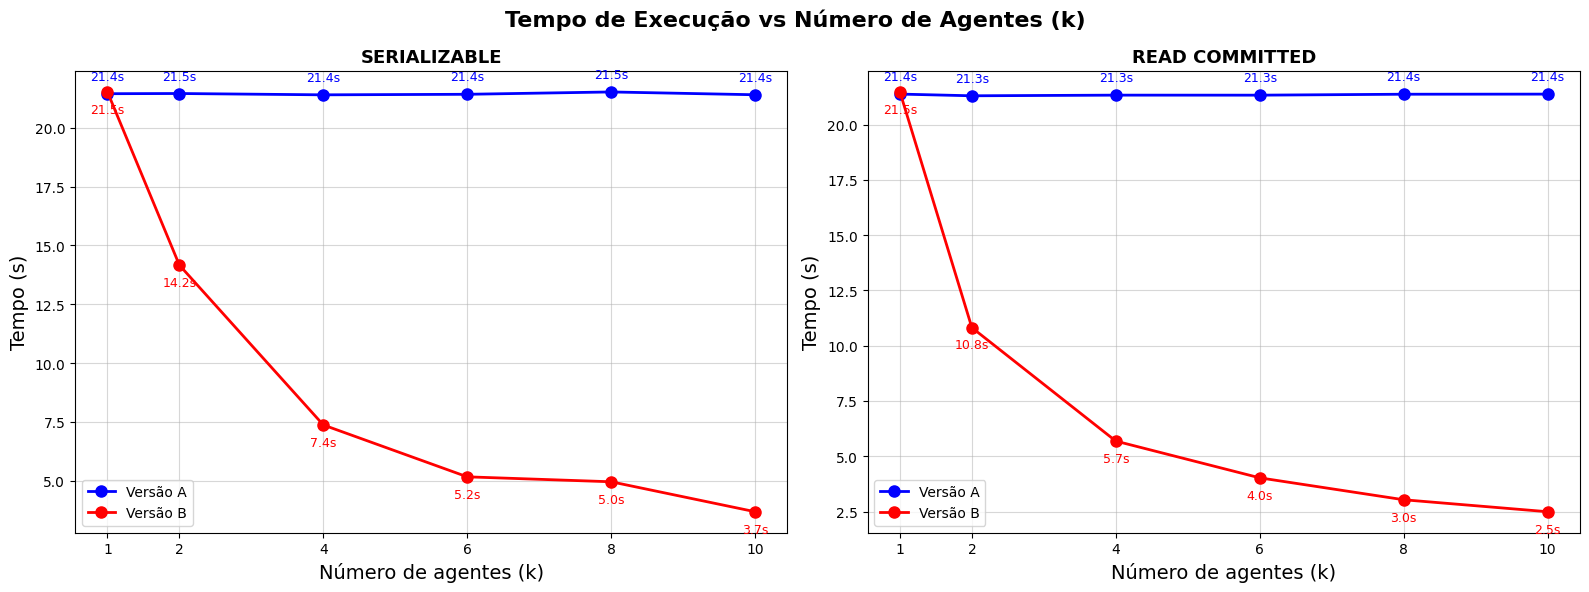

In [7]:
all_runner = ExperimentRunner()
all_runner.run_all_experiments()
all_runner.plot_results()

## Tarefa 19

In [8]:
all_runner.create_retry_table()

Nível de Isolamento: READ COMMITTED
 k  Min_A  Max_A Avg_A  Min_B  Max_B Avg_B
 1      1      1  1.00      1      1  1.00
 2      1      1  1.00      1      2  1.01
 4      1      1  1.00      1      3  1.05
 6      1      1  1.00      1      4  1.06
 8      1      1  1.00      1      3  1.06
10      1      1  1.00      1      3  1.07
Nível de Isolamento: SERIALIZABLE
 k  Min_A  Max_A Avg_A  Min_B  Max_B Avg_B
 1      1      1  1.00      1      1  1.00
 2      1     37  2.00      1      7  1.48
 4      1    121  3.88      1      7  1.39
 6      1     60  4.96      1      7  1.59
 8      1     54  5.47      1     11  2.06
10      1     41  6.02      1     12  2.02


## Tarefa 20

Vamos analisar os gráficos separadamente para cada versão da transação.
Para a versão A:
Se manteve em uma constante de 200 (com breves variações em ambas as execuções) isso se deve ao fato de que apenas uma thread consegue reservar um assento por vez, fazendo com que as outras threads esperem a liberação do lock. Essa justificativa aplicasse de maneira independente ao nível de isolamento utilizado, pois, ambos os níveis só permitem novas leituras de dados uma vez que a transação atual seja finalizada (commit ou rollback).

Para a versão B:
No nível de isolamento SERIALIZABLE, o tempo foi diminuindo a medida que o número de agentes aumentava, isso se deve ao fato de que mais threads estão tentando reservar assentos simultaneamente, aumentando a chance de sucesso em cada tentativa, porém, observa-se que quando a quantidade de agentes ultrapassa 6, o tempo começa a aumentar novamente, isso se deve ao fato de que muitas threads estão competindo pelos mesmos recursos, causando contenção e aumentando o tempo de espera. Já no nível READ COMMITTED, o tempo diminui de forma mais consistente com o aumento do número de agentes, isso se deve ao fato de que esse nível de isolamento permite maior concorrência, reduzindo a contenção entre as threads e melhorando o desempenho geral do sistema, uma vez que o read commited permite leitura de dados já commitados, e uma vez que temos um commit já no meio, é permitida que outras leituras sejam feitas já naquele momento antes mesmo da escolha do assento.

No geral a versão B se mostrou mais eficiente, principalmente no nível READ COMMITTED, devido a sua capacidade de permitir maior concorrência e reduzir a contenção entre as threads uma vez que as outrhas threads não dependiam da escolha do assento (demorava 1 segundo) de outra thread.